<a href="https://colab.research.google.com/github/ramsaher/DEVF_Master_Ciencias_de_Datos/blob/main/An%C3%A1lisis_Cluster_Obesidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Recolección de datos

Se importan los datos desde Kaggle. Se ocupa el código
que sugiere la plataforma para siempre tener los últimos datos disponibles

Fabio Mendoza Palechor, and ,Alexis de la Hoz Manotas. (2023). Obesity or CVD risk (Classify/Regressor/Cluster) [Dataset]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/7009925

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "ObesityDataSet.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aravindpcoder/obesity-or-cvd-risk-classifyregressorcluster",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_2123/1715867153.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'obesity-or-cvd-risk-classifyregressorcluster' dataset.
First 5 records:    Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Tr

In [ ]:
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


#EDA

Un análisis básico exploratorio para entender mejor los datos y plantaernos una buena hipótesis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

The attributes related with eating habits are: Frequent consumption of high caloric food (FAVC), Frequency of consumption of vegetables (FCVC), Number of main meals (NCP), Consumption of food between meals (CAEC), Consumption of water daily (CH20), and Consumption of alcohol (CALC). The attributes related with the physical condition are: Calories consumption monitoring (SCC), Physical activity frequency (FAF), Time using technology devices (TUE), Transportation used (MTRANS) variables obtained : Gender, Age, Height and Weight.

NObesity values are:

•Underweight Less than 18.5 •Normal 18.5 to 24.9 •Overweight 25.0 to 29.9 •Obesity I 30.0 to 34.9 •Obesity II 35.0 to 39.9 •Obesity III Higher than 40

In [ ]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


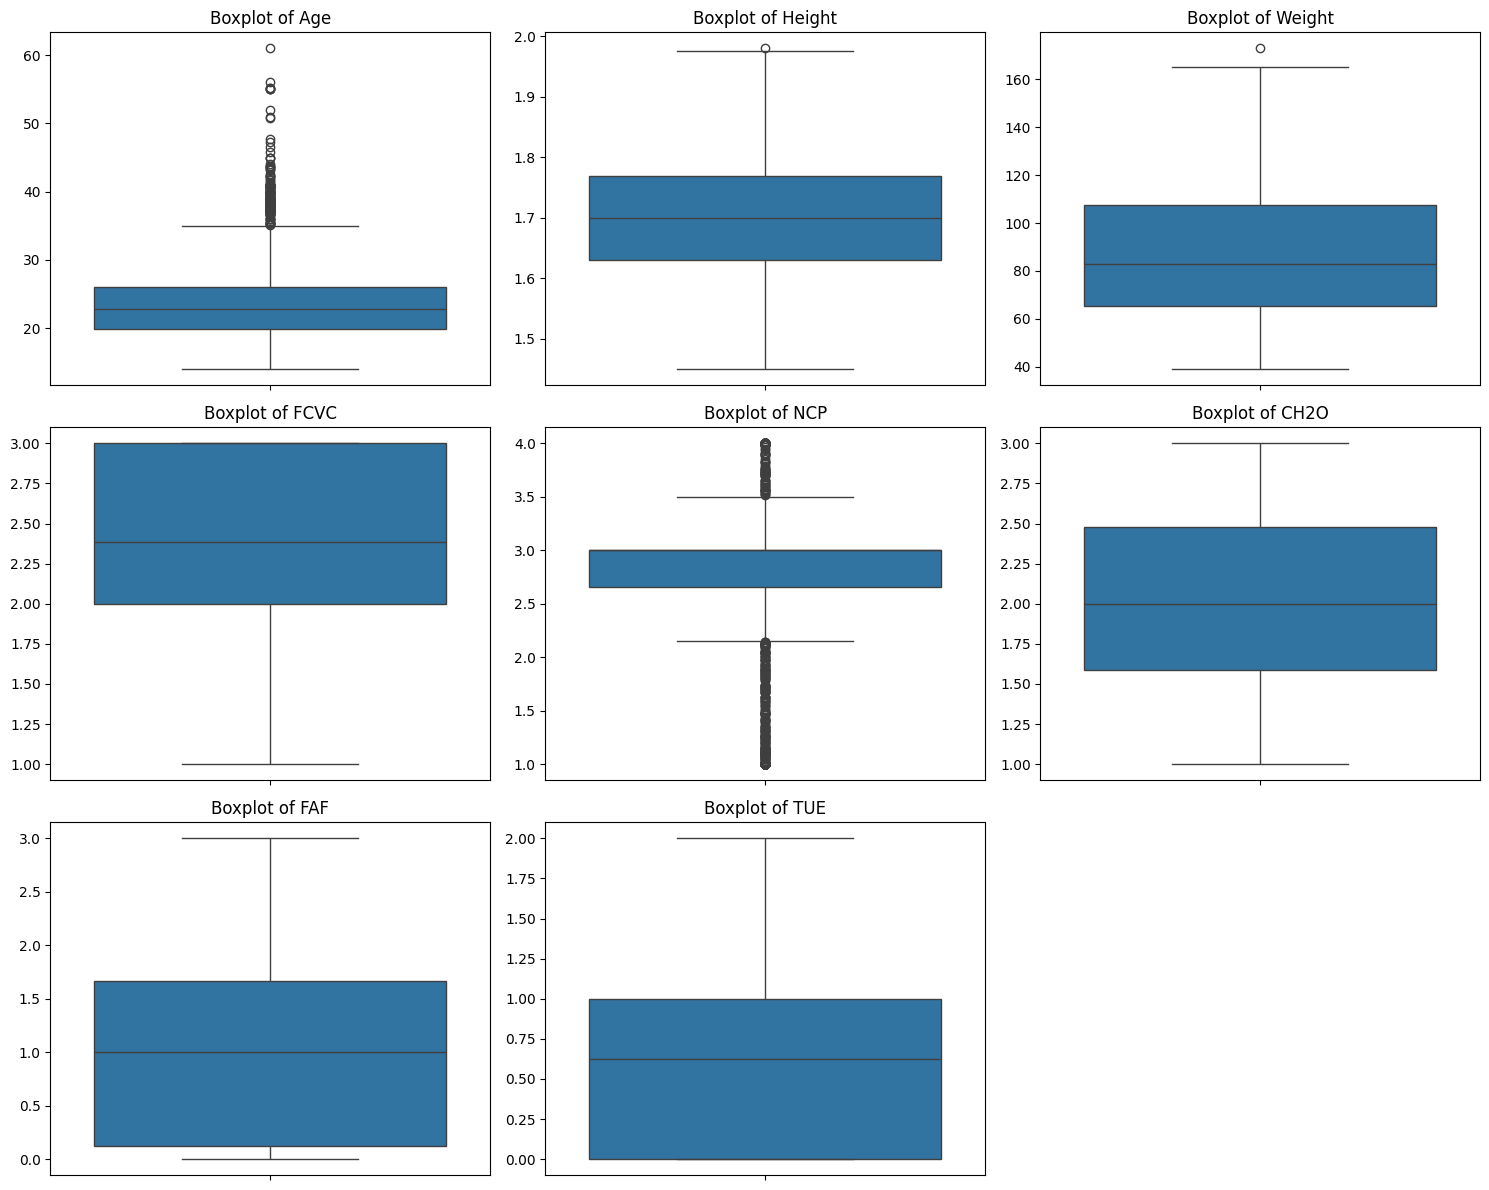

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Determine the number of rows and columns for subplots
num_numerical_cols = len(numerical_cols)
num_rows = (num_numerical_cols + 2) // 3  # Adjust as needed, e.g., 3 columns per row
num_cols = 3

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')
    plt.tight_layout()

plt.show()

- La muestra nos enseña una población mas jóven que la población general de México, Perú y Colombia. La media muestral es de 22 años aprox mientras la poblacional se considera arriba de 30 años.

- Se sabe que la muestra se tomó desde una plataforma web por lo que esto puede esta causando el sesgo de edad. Consideraremos a la muestra como una población con huella digital.

/tmp/ipykernel_2123/686948043.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_2123/686948043.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_2123/686948043.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_2123/686948043.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `leg

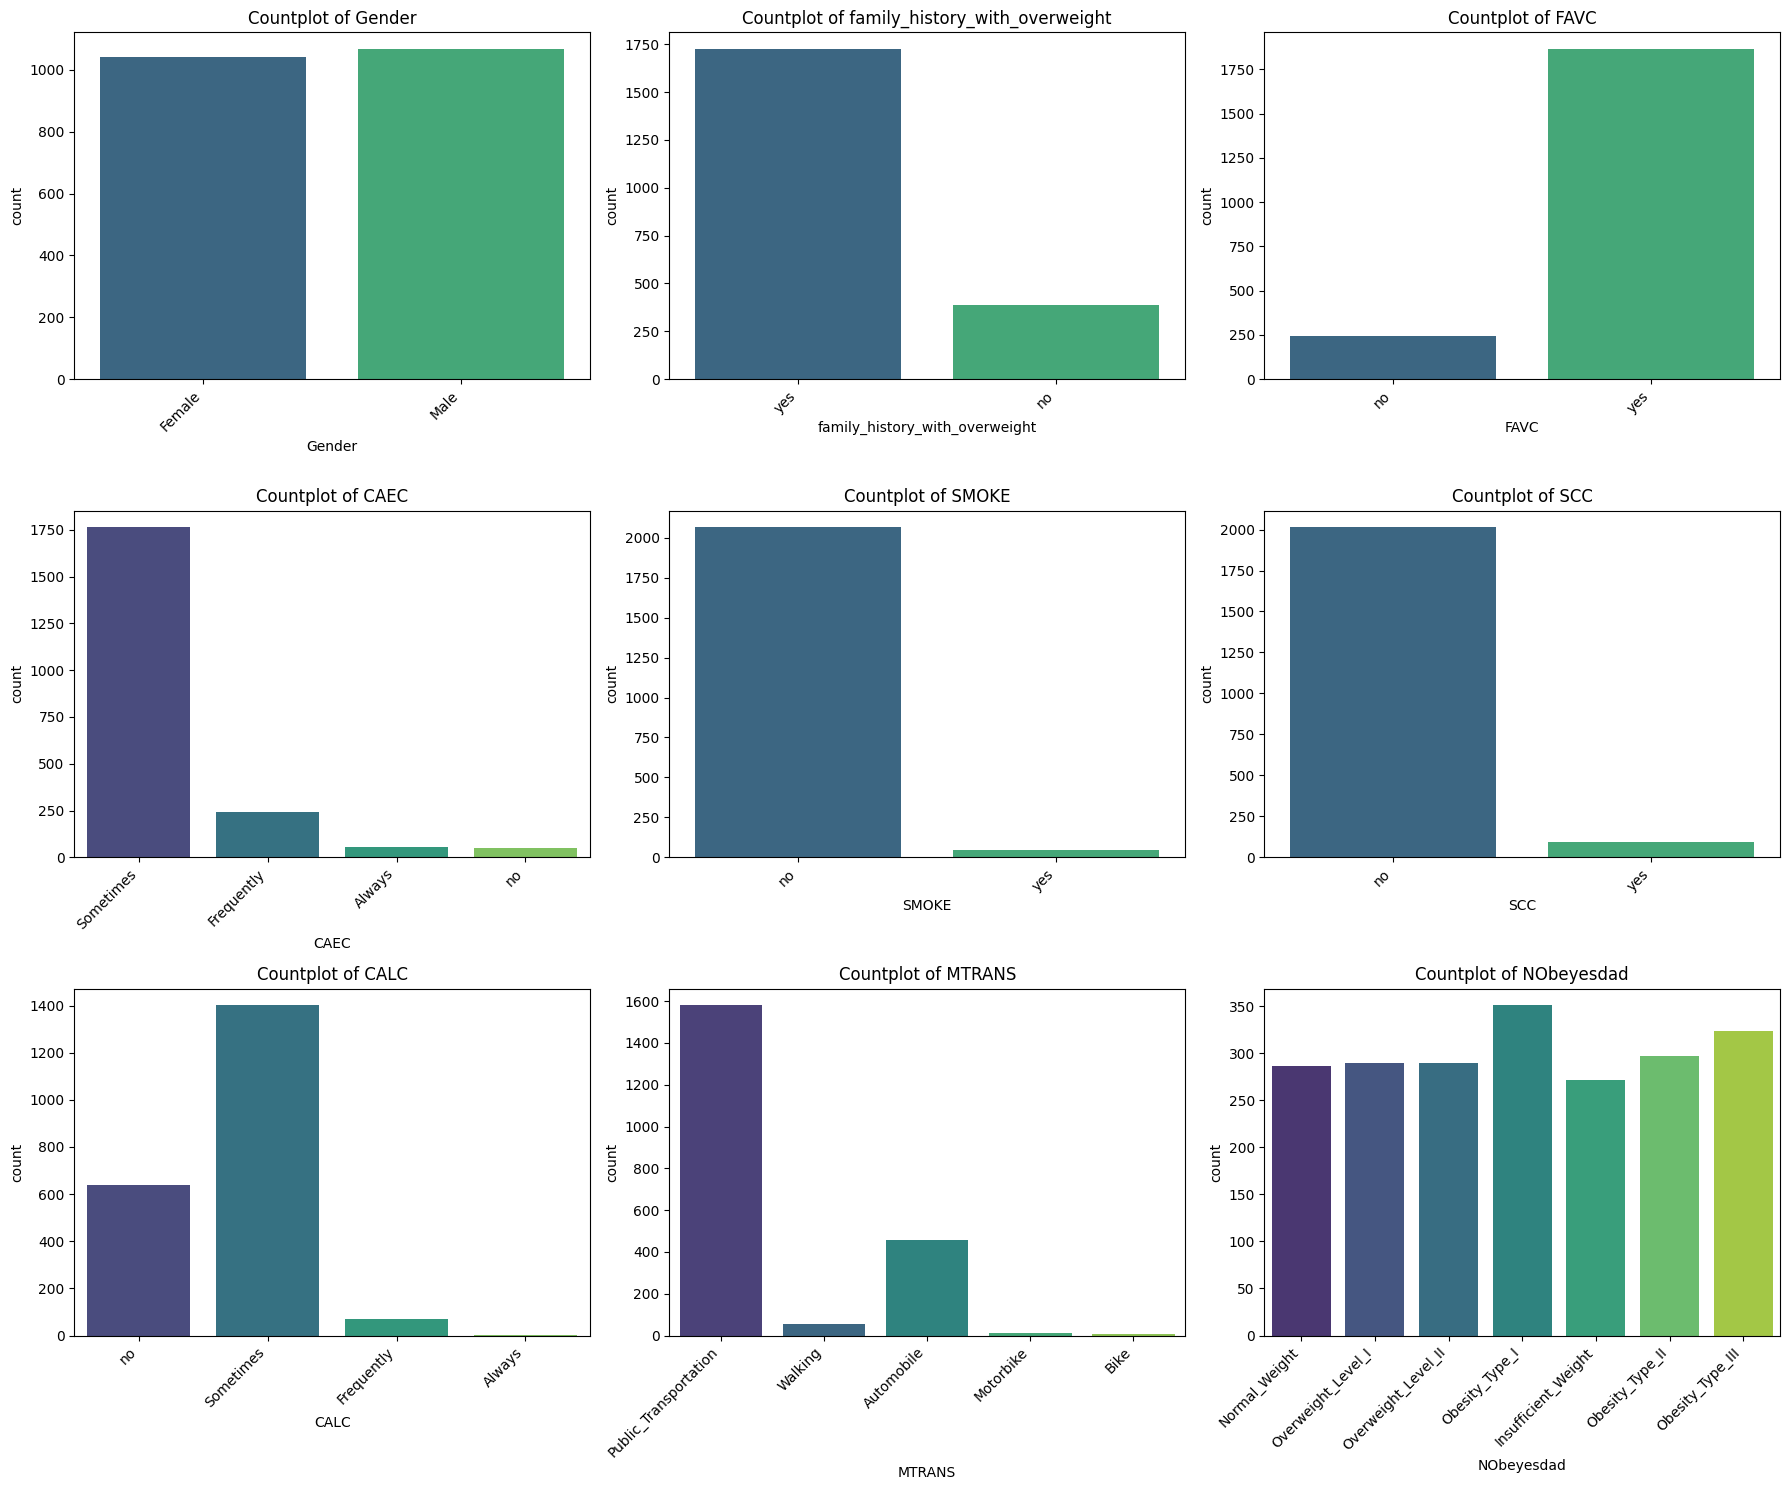

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get object (non-numeric) columns
object_cols = df.select_dtypes(include=['object']).columns

# Determine the number of rows and columns for subplots
num_object_cols = len(object_cols)
num_rows = (num_object_cols + 2) // 3  # Adjust as needed, e.g., 3 columns per row
num_cols = 3

plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, col in enumerate(object_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
    plt.tight_layout()

plt.show()

##Encoding de variables categóricas:

DICCIONARIO DE ENCODING - MAPEOS LABEL ENCODER


CAEC - Consumo de alimentos entre comidas
Always        -> 0
Frequently    -> 1
Sometimes     -> 2
no            -> 3

CALC - Consumo de alcohol
Always        -> 0
Frequently    -> 1
Sometimes     -> 2
no            -> 3

MTRANS - Medio de transporte
Automobile              -> 0
Bike                    -> 1
Motorbike               -> 2
Public_Transportation   -> 3
Walking                 -> 4

NObeyesdad - Nivel de obesidad
Insufficient_Weight     -> 0
Normal_Weight           -> 1
Obesity_Type_I          -> 2
Obesity_Type_II         -> 3
Obesity_Type_III        -> 4
Overweight_Level_I      -> 5
Overweight

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Get object (categorical) columns
object_cols = df.select_dtypes(include=['object']).columns

for col in object_cols:
    unique_values = df[col].nunique()
    if unique_values == 2:
        # One-Hot Encoding for binary variables
        df_encoded = pd.get_dummies(df_encoded, columns=[col], prefix=col, drop_first=True)
    elif unique_values > 2:
        # Label Encoding for multi-class variables
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        print(f"Label Encoded '{col}': {list(le.classes_)} mapped to {list(le.transform(le.classes_))}")

print("\nFirst 5 rows of the encoded DataFrame:")
print(df_encoded.head())

Label Encoded 'CAEC': ['Always', 'Frequently', 'Sometimes', 'no'] mapped to [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Label Encoded 'CALC': ['Always', 'Frequently', 'Sometimes', 'no'] mapped to [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Label Encoded 'MTRANS': ['Automobile', 'Bike', 'Motorbike', 'Public_Transportation', 'Walking'] mapped to [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Label Encoded 'NObeyesdad': ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II'] mapped to [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

First 5 rows of the encoded DataFrame:
    Age  Height  Weight  FCVC  NCP  CAEC  CH2O  FAF  TUE  CALC  MTRANS  \
0  21.0    1.62    64.0   2.0  3.0     2   2.0  0.0  1.0     3       3   
1  21.0    1.52    56.0   3.0  3.0     2   3.0  3.0  0.0     2       3   
2  23.0    1.80    77.0   2.0  3.0 

In [ ]:
for col in df_encoded.select_dtypes(include=['bool']).columns:
    df_encoded[col] = df_encoded[col].astype(int)

print("First 5 rows of df_encoded with boolean columns converted to numbers:")
print(df_encoded.head())

First 5 rows of df_encoded with boolean columns converted to numbers:
    Age  Height  Weight  FCVC  NCP  CAEC  CH2O  FAF  TUE  CALC  MTRANS  \
0  21.0    1.62    64.0   2.0  3.0     2   2.0  0.0  1.0     3       3   
1  21.0    1.52    56.0   3.0  3.0     2   3.0  3.0  0.0     2       3   
2  23.0    1.80    77.0   2.0  3.0     2   2.0  2.0  1.0     1       3   
3  27.0    1.80    87.0   3.0  3.0     2   2.0  2.0  0.0     1       4   
4  22.0    1.78    89.8   2.0  1.0     2   2.0  0.0  0.0     2       3   

   NObeyesdad  Gender_Male  family_history_with_overweight_yes  FAVC_yes  \
0           1            0                                   1         0   
1           1            0                                   1         0   
2           1            1                                   1         0   
3           5            1                                   0         0   
4           6            1                                   0         0   

   SMOKE_yes  SCC_yes  
0   

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 2111 non-null   float64
 1   Height                              2111 non-null   float64
 2   Weight                              2111 non-null   float64
 3   FCVC                                2111 non-null   float64
 4   NCP                                 2111 non-null   float64
 5   CAEC                                2111 non-null   int64  
 6   CH2O                                2111 non-null   float64
 7   FAF                                 2111 non-null   float64
 8   TUE                                 2111 non-null   float64
 9   CALC                                2111 non-null   int64  
 10  MTRANS                              2111 non-null   int64  
 11  NObeyesdad                          2111 no

# Correlaciones

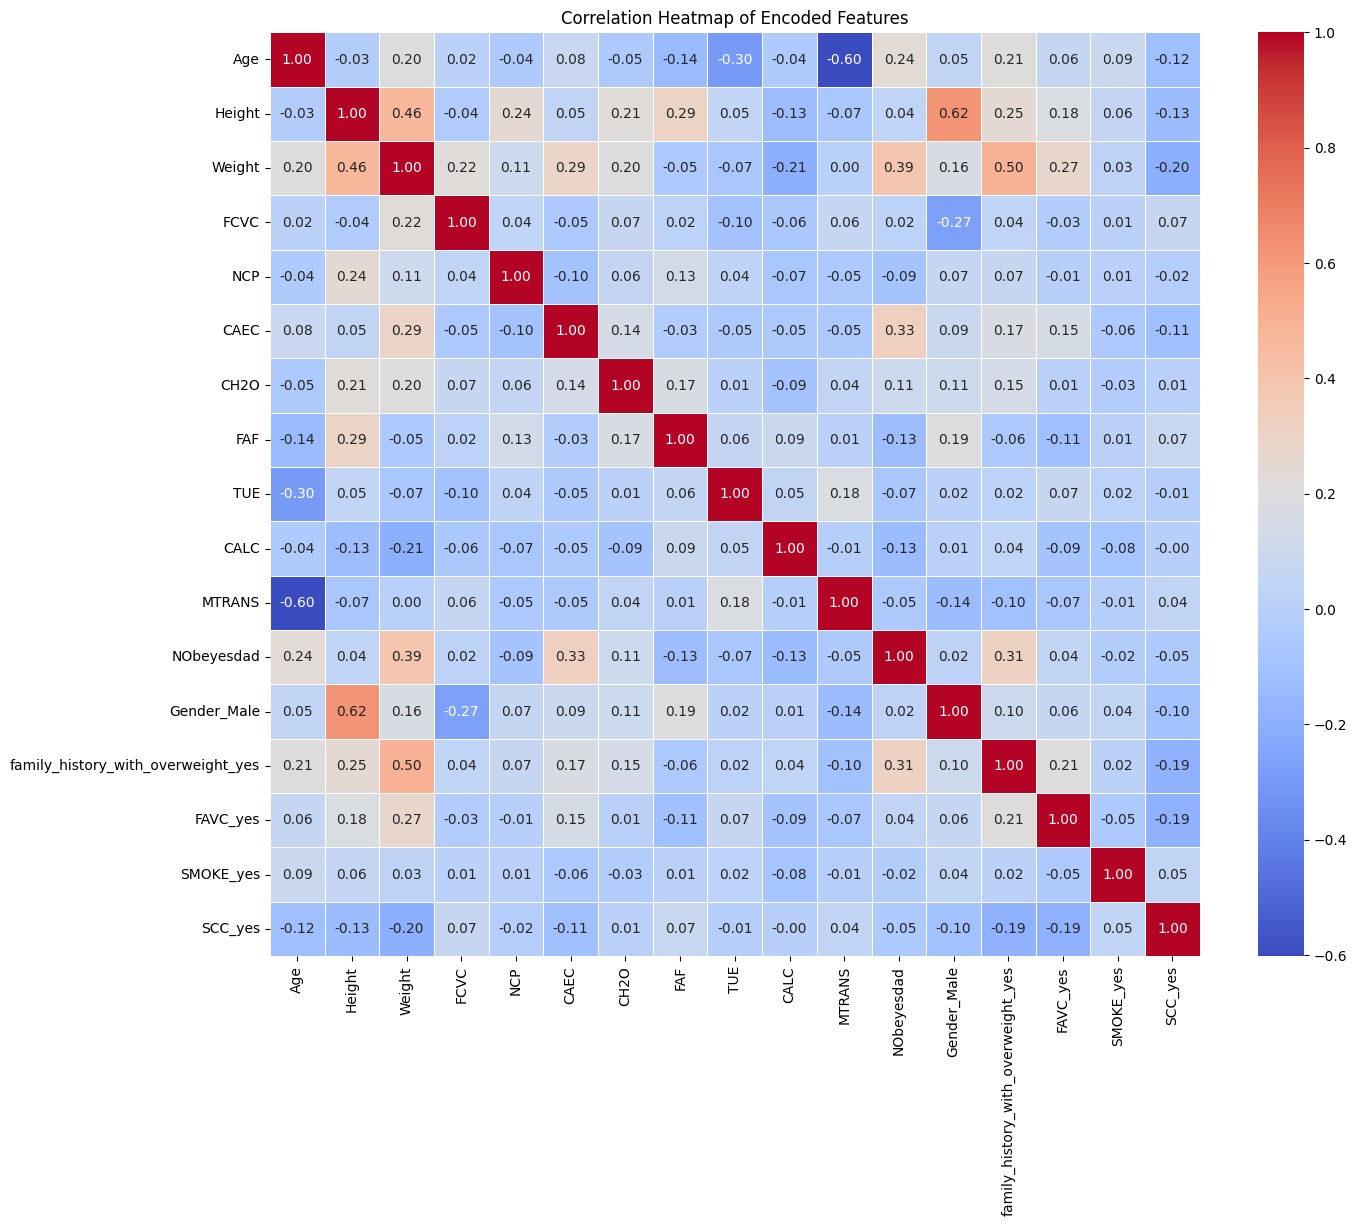

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Encoded Features')
plt.show()

#Clusters

In [ ]:
df_features = df_encoded.drop('NObeyesdad', axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Scale the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features)

# Apply KMeans clustering (e.g., 4 clusters as an initial guess)
# In a real scenario, you'd use methods like the elbow method or silhouette score to find optimal k.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # n_init is set to 10 to suppress warning
df_encoded['Cluster'] = kmeans.fit_predict(df_scaled)

print("First 5 rows with cluster labels:")
print(df_encoded.head())

print("\nCluster distribution:")
print(df_encoded['Cluster'].value_counts())



First 5 rows with cluster labels:
    Age  Height  Weight  FCVC  NCP  CAEC  CH2O  FAF  TUE  CALC  MTRANS  \
0  21.0    1.62    64.0   2.0  3.0     2   2.0  0.0  1.0     3       3   
1  21.0    1.52    56.0   3.0  3.0     2   3.0  3.0  0.0     2       3   
2  23.0    1.80    77.0   2.0  3.0     2   2.0  2.0  1.0     1       3   
3  27.0    1.80    87.0   3.0  3.0     2   2.0  2.0  0.0     1       4   
4  22.0    1.78    89.8   2.0  1.0     2   2.0  0.0  0.0     2       3   

   NObeyesdad  Gender_Male  family_history_with_overweight_yes  FAVC_yes  \
0           1            0                                   1         0   
1           1            0                                   1         0   
2           1            1                                   1         0   
3           5            1                                   0         0   
4           6            1                                   0         0   

   SMOKE_yes  SCC_yes  Cluster  
0          0        0        3 

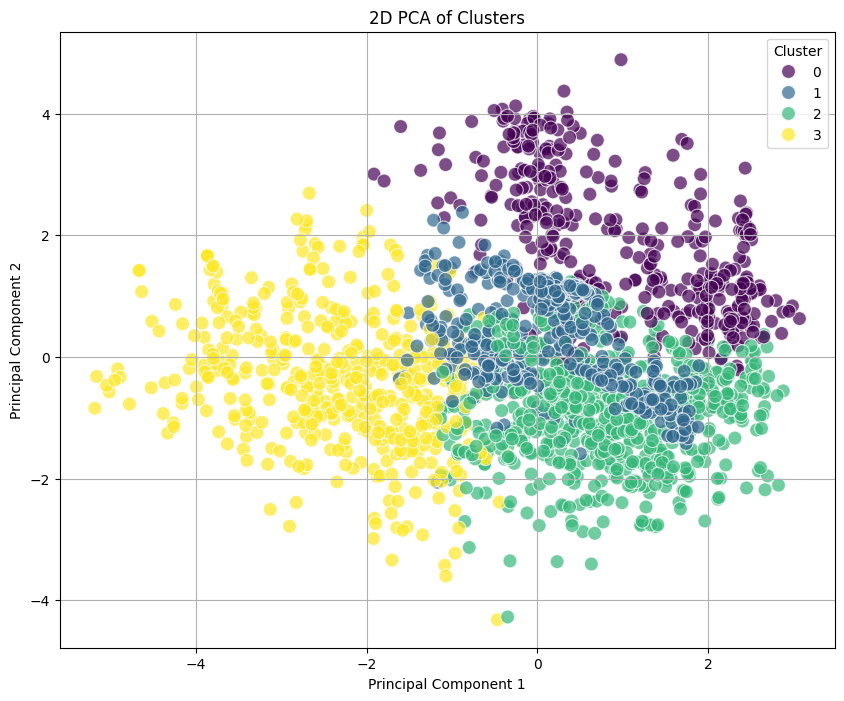

In [ ]:
# Optional: Visualize clusters (e.g., using PCA for 2D visualization)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(data=df_pca, columns=['principal_component_1', 'principal_component_2'])

df_pca['Cluster'] = df_encoded['Cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='Cluster',
    data=df_pca,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('2D PCA of Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [ ]:
import plotly.express as px
from sklearn.decomposition import PCA
import pandas as pd

# Apply PCA with 3 components
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled)

# Create a DataFrame for 3D PCA visualization
df_pca_3d = pd.DataFrame(data=df_pca_3d, columns=['principal_component_1', 'principal_component_2', 'principal_component_3'])

df_pca_3d['Cluster'] = df_encoded['Cluster']

# Create a 3D scatter plot using Plotly Express
fig = px.scatter_3d(df_pca_3d,
                    x='principal_component_1',
                    y='principal_component_2',
                    z='principal_component_3',
                    color='Cluster',
                    symbol='Cluster',
                    title='3D PCA of Clusters',
                    labels={'principal_component_1': 'Principal Component 1',
                            'principal_component_2': 'Principal Component 2',
                            'principal_component_3': 'Principal Component 3'})
fig.show()

##Elbow Method

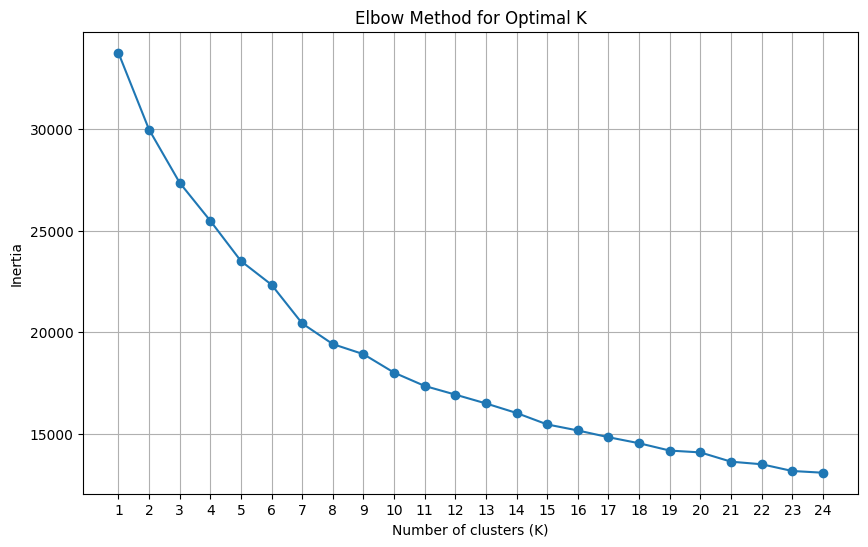

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 'df_scaled' should be available from previous steps

# List to hold the inertia values
inertia = []

# List to hold the number of clusters
k_values = range(1, 25) # Testing k from 1 to 10

# Loop through different numbers of clusters
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow method graph
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show()


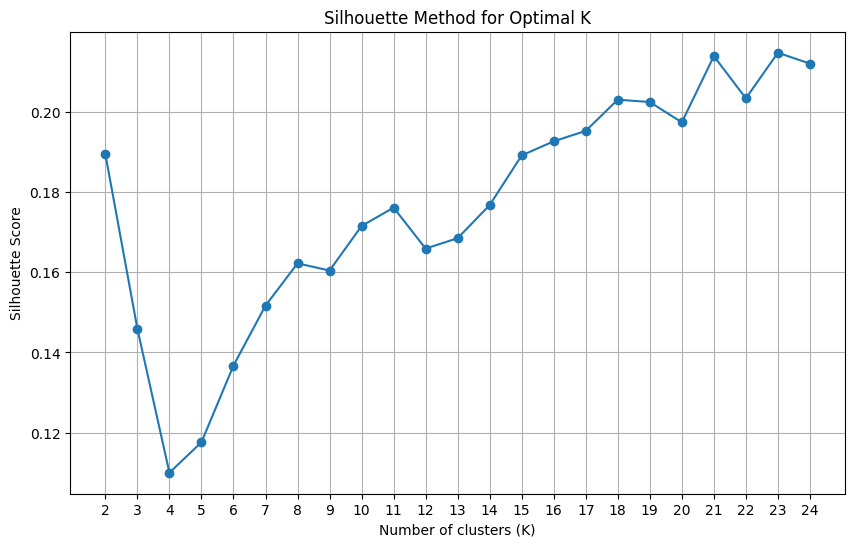

In [ ]:
from sklearn.metrics import silhouette_score

# List to hold the silhouette scores
silhouette_scores = []

# List to hold the number of clusters (start from 2 for silhouette score)
k_values_silhouette = range(2, 25)

# Loop through different numbers of clusters
for k in k_values_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    score = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the silhouette method graph
plt.figure(figsize=(10, 6))
plt.plot(k_values_silhouette, silhouette_scores, marker='o', linestyle='-')
plt.title('Silhouette Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values_silhouette)
plt.grid(True)
plt.show()



*   Se porbará con k = 8 basado en el método del codo y Silhouette Score



In [ ]:
# In a real scenario, you'd use methods like the elbow method or silhouette score to find optimal k.
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10) # n_init is set to 10 to suppress warning
df_encoded['Cluster'] = kmeans.fit_predict(df_scaled)

print("First 5 rows with cluster labels:")
print(df_encoded.head())

print("\nCluster distribution:")
print(df_encoded['Cluster'].value_counts())

First 5 rows with cluster labels:
    Age  Height  Weight  FCVC  NCP  CAEC  CH2O  FAF  TUE  CALC  MTRANS  \
0  21.0    1.62    64.0   2.0  3.0     2   2.0  0.0  1.0     3       3   
1  21.0    1.52    56.0   3.0  3.0     2   3.0  3.0  0.0     2       3   
2  23.0    1.80    77.0   2.0  3.0     2   2.0  2.0  1.0     1       3   
3  27.0    1.80    87.0   3.0  3.0     2   2.0  2.0  0.0     1       4   
4  22.0    1.78    89.8   2.0  1.0     2   2.0  0.0  0.0     2       3   

   NObeyesdad  Gender_Male  family_history_with_overweight_yes  FAVC_yes  \
0           1            0                                   1         0   
1           1            0                                   1         0   
2           1            1                                   1         0   
3           5            1                                   0         0   
4           6            1                                   0         0   

   SMOKE_yes  SCC_yes  Cluster  
0          0        0        2 

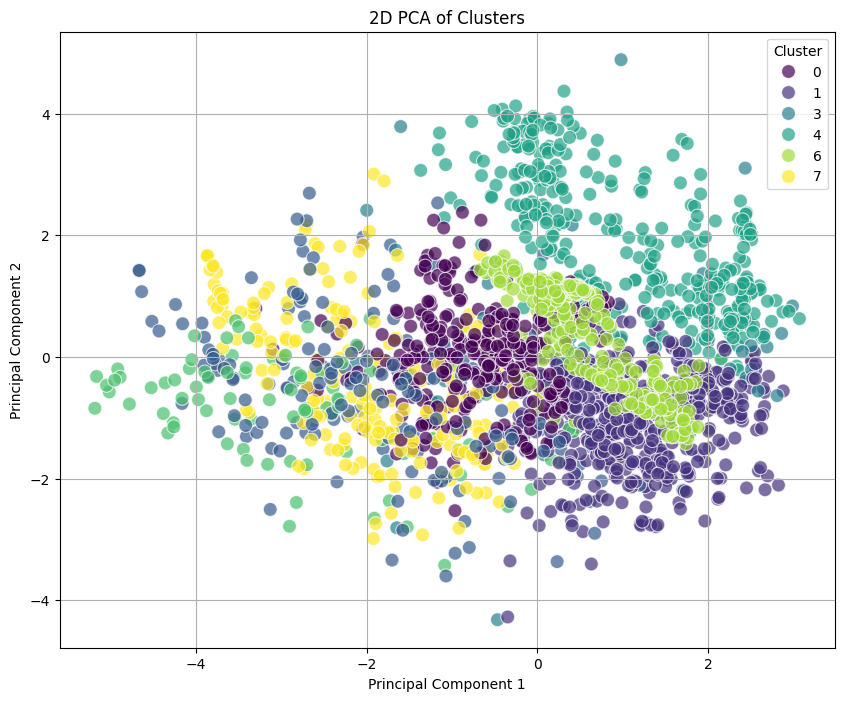

In [ ]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(data=df_pca, columns=['principal_component_1', 'principal_component_2'])

df_pca['Cluster'] = df_encoded['Cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='Cluster',
    data=df_pca,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('2D PCA of Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [ ]:
# Apply PCA with 3 components
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled)

# Create a DataFrame for 3D PCA visualization
df_pca_3d = pd.DataFrame(data=df_pca_3d, columns=['principal_component_1', 'principal_component_2', 'principal_component_3'])

df_pca_3d['Cluster'] = df_encoded['Cluster']

# Create a 3D scatter plot using Plotly Express
fig = px.scatter_3d(df_pca_3d,
                    x='principal_component_1',
                    y='principal_component_2',
                    z='principal_component_3',
                    color='Cluster',
                    symbol='Cluster',
                    title='3D PCA of Clusters',
                    labels={'principal_component_1': 'Principal Component 1',
                            'principal_component_2': 'Principal Component 2',
                            'principal_component_3': 'Principal Component 3'})
fig.show()

In [ ]:
print("Cluster Profiling (Mean values for each feature within each cluster):")
cluster_profiles = df_encoded.groupby('Cluster').mean()
print(cluster_profiles)

Cluster Profiling (Mean values for each feature within each cluster):
               Age    Height      Weight      FCVC       NCP      CAEC  \
Cluster                                                                  
0        22.416353  1.656094   77.173561  2.334810  2.256469  1.727273   
1        22.308565  1.785604   92.416857  2.219906  2.905926  1.923358   
2        21.686683  1.648933   65.694781  2.376723  2.641281  1.683333   
3        28.312669  1.737161   91.206810  2.471433  2.727273  1.681818   
4        34.446325  1.703146   91.536710  2.337162  2.617384  1.943820   
5        20.467392  1.643994   61.900903  2.594475  2.631595  1.615385   
6        23.342754  1.686335  117.891633  2.963492  3.003021  2.011628   
7        20.276401  1.642664   56.364333  2.275834  2.433914  1.799127   

             CH2O       FAF       TUE      CALC    MTRANS  NObeyesdad  \
Cluster                                                                 
0        1.814121  0.940875  0.845436  2.72

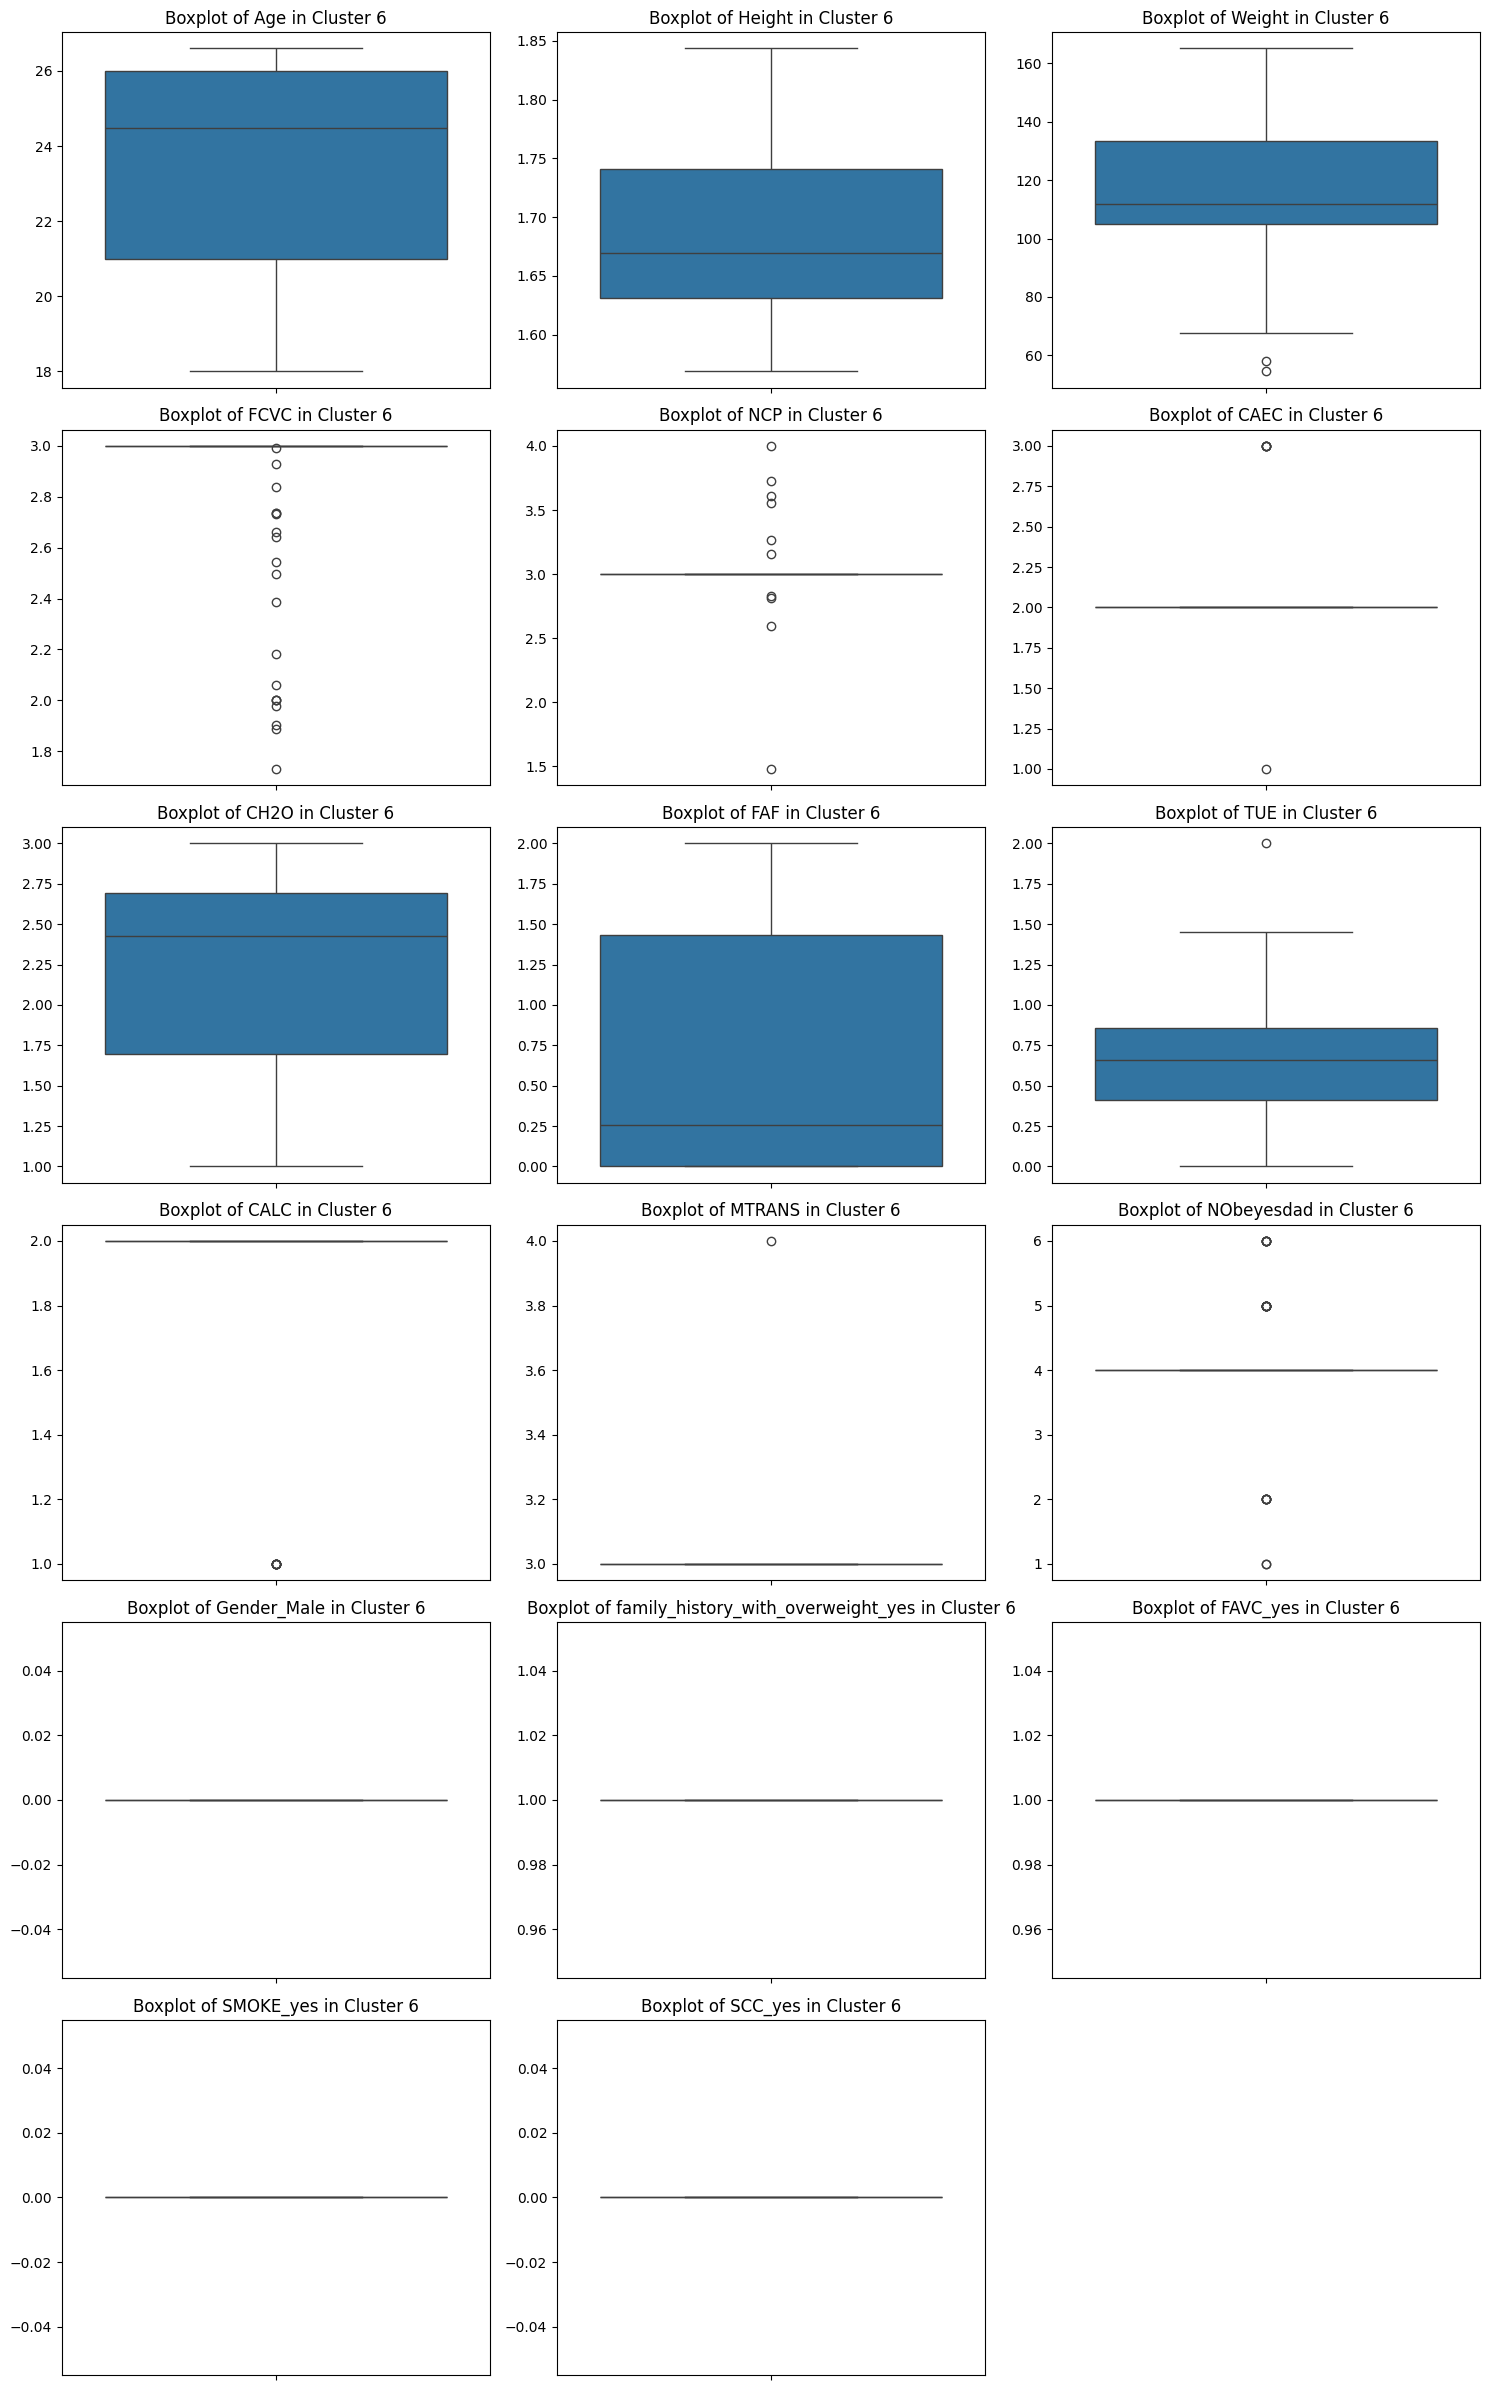

In [ ]:
# Filter the DataFrame for Cluster 6
df_cluster_6 = df_encoded[df_encoded['Cluster'] == 6]

# Get all columns that are numerical (float or int)
all_numerical_cols = df_cluster_6.select_dtypes(include=['float64', 'int64']).columns

# Exclude the 'Cluster' column from this list if it exists.
# This approach is more robust as it won't raise an error if 'Cluster' is unexpectedly missing.
numerical_cols_to_plot = [col for col in all_numerical_cols if col != 'Cluster']

# Determine the number of rows and columns for subplots
num_numerical_cols = len(numerical_cols_to_plot)
num_rows = (num_numerical_cols + 2) // 3  # Aim for 3 columns per row
num_cols = 3

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(numerical_cols_to_plot):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df_cluster_6[col])
    plt.title(f'Boxplot of {col} in Cluster 6')
    plt.ylabel('')
    plt.tight_layout()

plt.show()

--- Descriptive Statistics for Cluster 6 (Numerical Features) ---
              Age      Height      Weight        FCVC         NCP        CH2O  \
count  344.000000  344.000000  344.000000  344.000000  344.000000  344.000000   
mean    23.342754    1.686335  117.891633    2.963492    3.003021    2.220383   
std      2.823270    0.063376   18.648119    0.175056    0.118879    0.596903   
min     18.000000    1.568543   54.500000    1.729824    1.478334    1.000000   
25%     21.001477    1.630878  105.051063    3.000000    3.000000    1.694937   
50%     24.486308    1.669196  111.936412    3.000000    3.000000    2.426011   
75%     26.000000    1.741059  133.351254    3.000000    3.000000    2.696239   
max     26.595893    1.843419  165.057269    3.000000    4.000000    3.000000   

              FAF         TUE  
count  344.000000  344.000000  
mean     0.667691    0.612003  
std      0.716327    0.295536  
min      0.000000    0.000000  
25%      0.000000    0.413382  
50%      0.2

/tmp/ipykernel_2123/3990607339.py:59: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2123/3990607339.py:59: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2123/3990607339.py:59: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2123/3990607339.py:59: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2123/3990607339.py:59: FutureWarning:



Passing `palette` without assigning `hue` is depreca

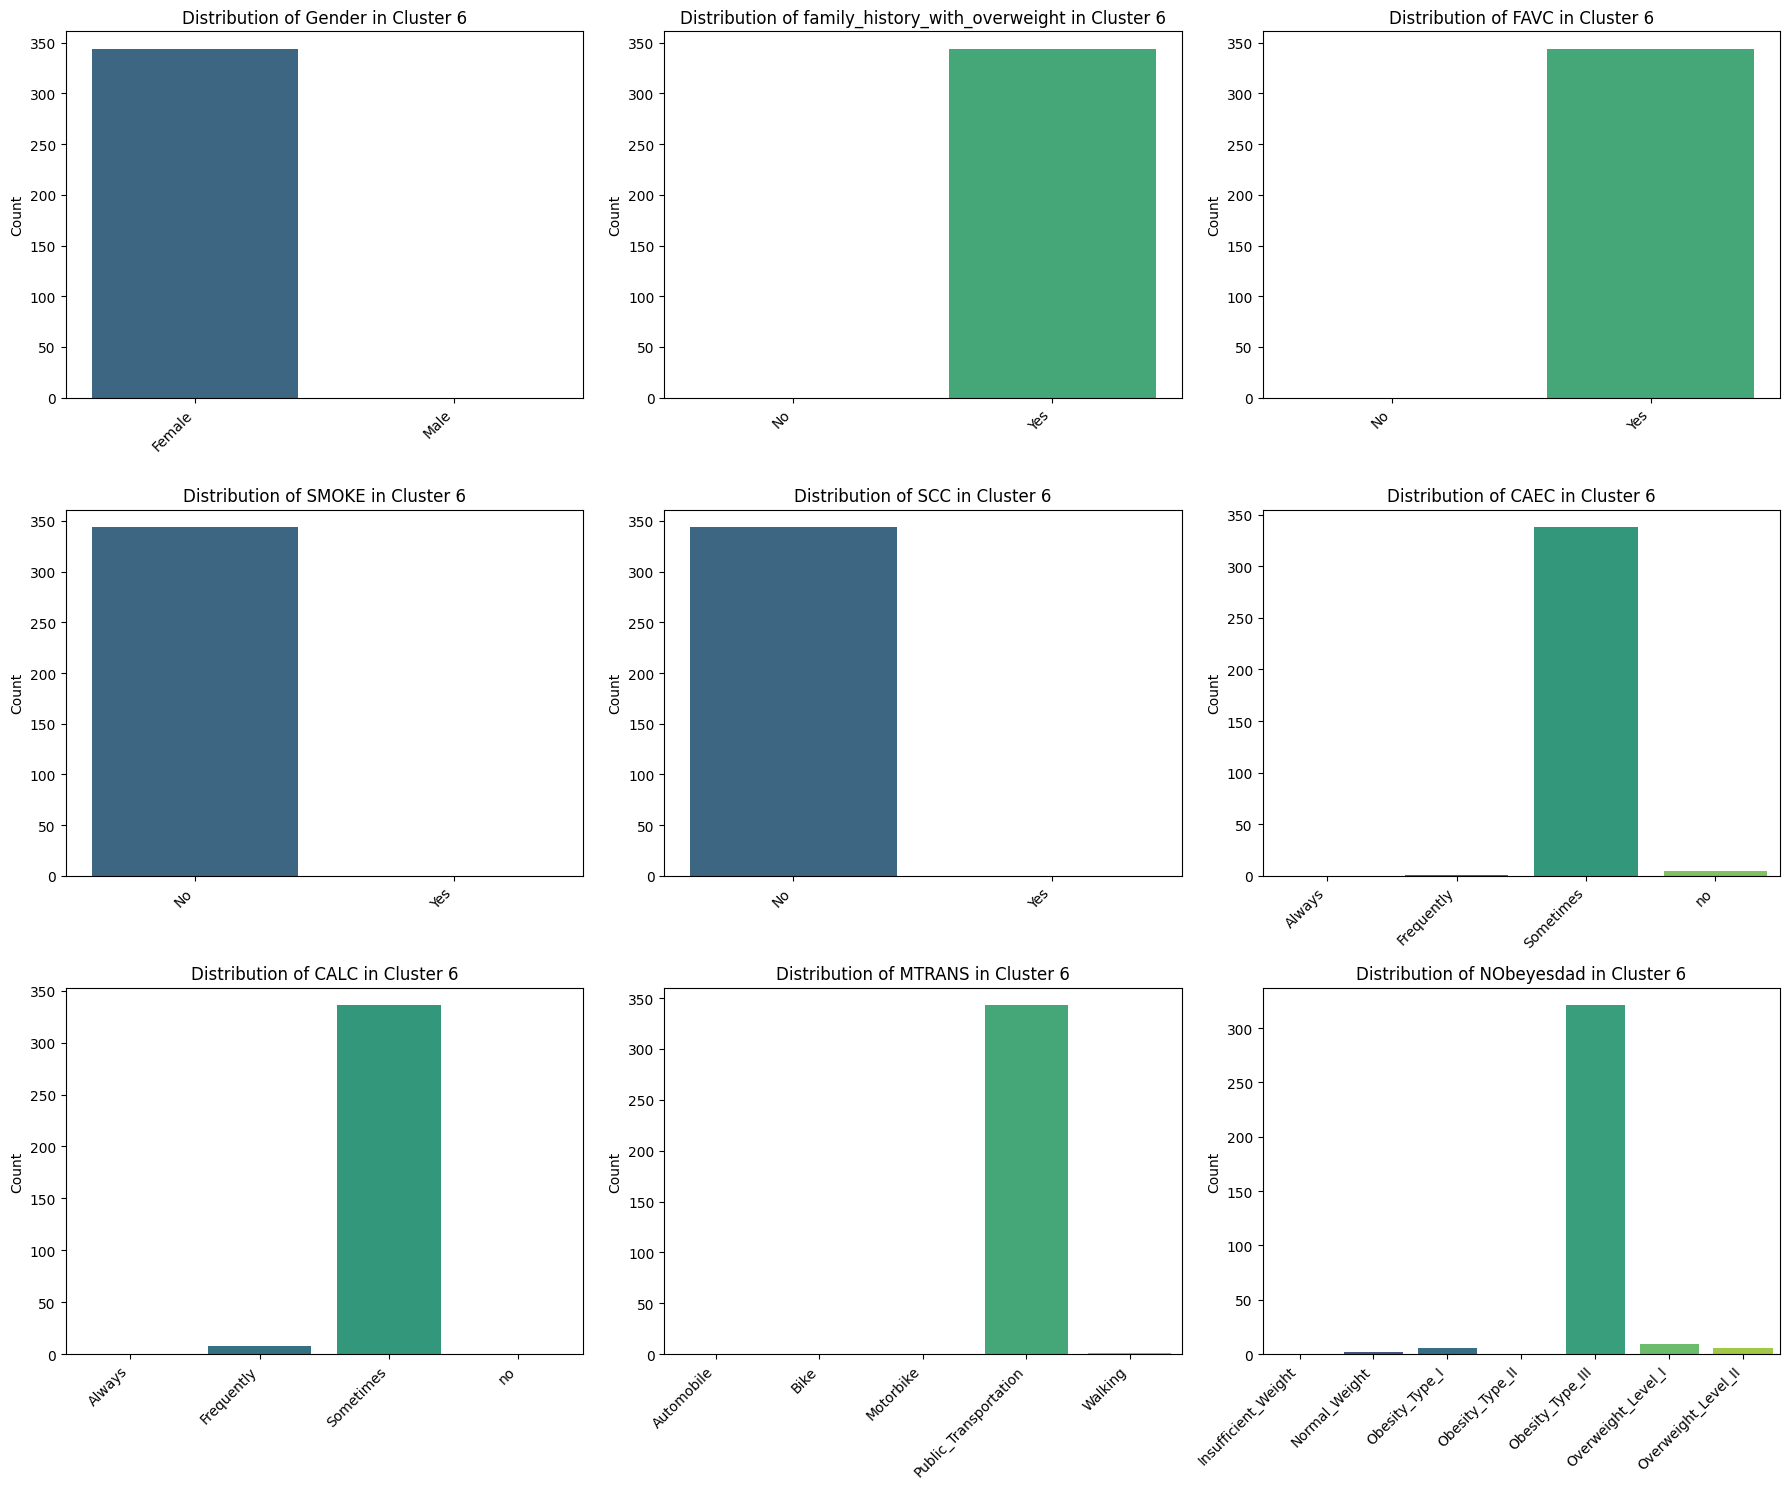


--- Interpretation Guide for Cluster 6 ---
Cluster 6 consists of 344 individuals. To describe this cluster:
- **Numerical Characteristics**: Review the 'Descriptive Statistics' table above for columns like 'Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', and 'TUE'. Pay attention to the mean, standard deviation, min, and max values to understand the central tendency and spread of these features within Cluster 6.
- **Categorical Characteristics**: Examine the 'Distributions for Cluster 6 (Categorical Features)' count plots. Each plot shows the frequency of different categories within this cluster for features like Gender, family history, eating habits (FAVC, CAEC, CALC, SCC), smoking habits (SMOKE), transportation (MTRANS), and their NObeyesdad (Obesity level).
  - For example, if 'FAVC_yes' (Frequent consumption of high caloric food) shows a high bar for 'Yes', it means this cluster tends to consume high-caloric food frequently.
  - If 'NObeyesdad' shows 'Obesity_Type_III' as t

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume df_encoded and df_cluster_6 are available from previous steps.
# Filter the DataFrame for Cluster 6 (re-defining it here for self-containment if needed)
df_cluster_6 = df_encoded[df_encoded['Cluster'] == 6]

# 1. Descriptive Statistics for numerical features in Cluster 6
print("--- Descriptive Statistics for Cluster 6 (Numerical Features) ---")
# List of original numerical columns
numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
print(df_cluster_6[numerical_cols].describe())

# Define mappings for label-encoded columns to make plots interpretable
caec_map = {0: 'Always', 1: 'Frequently', 2: 'Sometimes', 3: 'no'}
calc_map = {0: 'Always', 1: 'Frequently', 2: 'Sometimes', 3: 'no'}
mtrans_map = {0: 'Automobile', 1: 'Bike', 2: 'Motorbike', 3: 'Public_Transportation', 4: 'Walking'}
nobeyesdad_map = {0: 'Insufficient_Weight', 1: 'Normal_Weight', 2: 'Obesity_Type_I', 3: 'Obesity_Type_II', 4: 'Obesity_Type_III', 5: 'Overweight_Level_I', 6: 'Overweight_Level_II'}

# 2. Distributions for categorical (encoded) features in Cluster 6
print("\n--- Distributions for Cluster 6 (Categorical Features) ---")

# Binary encoded columns and their labels
binary_cols = ['Gender_Male', 'family_history_with_overweight_yes', 'FAVC_yes', 'SMOKE_yes', 'SCC_yes']
binary_labels = {
    'Gender_Male': {0: 'Female', 1: 'Male'},
    'family_history_with_overweight_yes': {0: 'No', 1: 'Yes'},
    'FAVC_yes': {0: 'No', 1: 'Yes'},
    'SMOKE_yes': {0: 'No', 1: 'Yes'},
    'SCC_yes': {0: 'No', 1: 'Yes'}
}

# Label encoded columns and their maps
label_encoded_cols = ['CAEC', 'CALC', 'MTRANS', 'NObeyesdad']
label_encoded_maps = {
    'CAEC': caec_map,
    'CALC': calc_map,
    'MTRANS': mtrans_map,
    'NObeyesdad': nobeyesdad_map
}

# Combine all categorical columns for plotting
all_categorical_cols = binary_cols + label_encoded_cols
num_cat_cols = len(all_categorical_cols)
num_rows_cat = (num_cat_cols + 2) // 3 # Aim for 3 columns per row
num_cols_cat = 3

plt.figure(figsize=(num_cols_cat * 6, num_rows_cat * 5))

for i, col in enumerate(all_categorical_cols):
    plt.subplot(num_rows_cat, num_cols_cat, i + 1)

    if col in binary_cols:
        # For binary columns, map 0/1 to meaningful labels
        plot_data = df_cluster_6[col].map(binary_labels[col])
        # Ensure consistent order for binary plots
        order_labels = [label_val for key, label_val in sorted(binary_labels[col].items())]
        sns.countplot(x=plot_data, palette='viridis', order=order_labels)
        plt.title(f'Distribution of {col.replace("_yes", "").replace("_Male", "")} in Cluster 6') # Clean up title
    elif col in label_encoded_cols:
        # For label encoded columns, map to original categories
        plot_data = df_cluster_6[col].map(label_encoded_maps[col])
        # Ensure consistent order for label encoded plots
        order_labels = [label_val for key, label_val in sorted(label_encoded_maps[col].items())]
        sns.countplot(x=plot_data, palette='viridis', order=order_labels)
        plt.title(f'Distribution of {col} in Cluster 6')

    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')
    plt.xlabel('') # Clear x-label as title is descriptive
    plt.tight_layout()

plt.show()

print(f"\n--- Interpretation Guide for Cluster 6 ---")
print(f"Cluster 6 consists of {len(df_cluster_6)} individuals. To describe this cluster:")
print(f"- **Numerical Characteristics**: Review the 'Descriptive Statistics' table above for columns like 'Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', and 'TUE'. Pay attention to the mean, standard deviation, min, and max values to understand the central tendency and spread of these features within Cluster 6.")
print(f"- **Categorical Characteristics**: Examine the 'Distributions for Cluster 6 (Categorical Features)' count plots. Each plot shows the frequency of different categories within this cluster for features like Gender, family history, eating habits (FAVC, CAEC, CALC, SCC), smoking habits (SMOKE), transportation (MTRANS), and their NObeyesdad (Obesity level).")
print(f"  - For example, if 'FAVC_yes' (Frequent consumption of high caloric food) shows a high bar for 'Yes', it means this cluster tends to consume high-caloric food frequently.")
print(f"  - If 'NObeyesdad' shows 'Obesity_Type_III' as the most frequent category, it indicates that individuals in Cluster 6 predominantly fall into that obesity level.")
print(f"  By analyzing these distributions, you can build a detailed profile for Cluster 6.")

#PCA

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd

# Assuming df_scaled is already available from previous steps

# Apply PCA with 4 components
pca = PCA(n_components=4)
pca.fit(df_scaled)

# Get the principal components (eigenvectors)
components = pca.components_

# Get the names of the original features
# df_features was created by dropping 'NObeyesdad' from df_encoded
original_features = df_features.columns

# Create a DataFrame to display the components
components_df = pd.DataFrame(components, columns=original_features,
                             index=[f'Principal Component {i+1}' for i in range(pca.n_components)])

print("--- Principal Components as Linear Combinations of Original Variables ---")
print(components_df)

--- Principal Components as Linear Combinations of Original Variables ---
                            Age    Height    Weight      FCVC       NCP  \
Principal Component 1  0.214286  0.448928  0.469304 -0.000416  0.135005   
Principal Component 2  0.536813 -0.331823  0.040168  0.080329 -0.192239   
Principal Component 3 -0.264036 -0.170945  0.316540  0.369233 -0.091056   
Principal Component 4  0.123049  0.070745  0.121963  0.529565  0.291996   

                           CAEC      CH2O       FAF       TUE      CALC  \
Principal Component 1  0.225261  0.202924  0.064880 -0.047612 -0.128607   
Principal Component 2  0.101928 -0.201730 -0.381969 -0.336565 -0.018699   
Principal Component 3  0.189640  0.129999 -0.270356  0.124490 -0.185884   
Principal Component 4 -0.209881  0.217527  0.229174 -0.304516 -0.253794   

                         MTRANS  Gender_Male  \
Principal Component 1 -0.178916     0.330461   
Principal Component 2 -0.397054    -0.253151   
Principal Component 3  0.45337

In [ ]:
# Apply PCA with 4 components
pca = PCA(n_components=3)
pca.fit(df_scaled)

# Get the principal components (eigenvectors)
components = pca.components_

# Get the names of the original features
# df_features was created by dropping 'NObeyesdad' from df_encoded
original_features = df_features.columns

# Create a DataFrame to display the components
components_df = pd.DataFrame(components, columns=original_features,
                             index=[f'Principal Component {i+1}' for i in range(pca.n_components)])

print("--- Principal Components as Linear Combinations of Original Variables ---")
print(components_df)

--- Principal Components as Linear Combinations of Original Variables ---
                            Age    Height    Weight      FCVC       NCP  \
Principal Component 1  0.214286  0.448928  0.469304 -0.000416  0.135005   
Principal Component 2  0.536813 -0.331823  0.040168  0.080329 -0.192239   
Principal Component 3 -0.264036 -0.170945  0.316540  0.369233 -0.091056   

                           CAEC      CH2O       FAF       TUE      CALC  \
Principal Component 1  0.225261  0.202924  0.064880 -0.047612 -0.128607   
Principal Component 2  0.101928 -0.201730 -0.381969 -0.336565 -0.018699   
Principal Component 3  0.189640  0.129999 -0.270356  0.124490 -0.185884   

                         MTRANS  Gender_Male  \
Principal Component 1 -0.178916     0.330461   
Principal Component 2 -0.397054    -0.253151   
Principal Component 3  0.453372    -0.412278   

                       family_history_with_overweight_yes  FAVC_yes  \
Principal Component 1                            0.376399  0

In [ ]:
# Apply PCA with 3 components
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled)

# Create a DataFrame for 3D PCA visualization
df_pca_3d = pd.DataFrame(data=df_pca_3d, columns=['principal_component_1', 'principal_component_2', 'principal_component_3'])

df_pca_3d['Cluster'] = df_encoded['Cluster']

# Create a 3D scatter plot using Plotly Express
fig = px.scatter_3d(df_pca_3d,
                    x='principal_component_1',
                    y='principal_component_2',
                    z='principal_component_3',
                    color='Cluster',
                    symbol='Cluster',
                    title='3D PCA of Clusters',
                    labels={'principal_component_1': 'Principal Component 1',
                            'principal_component_2': 'Principal Component 2',
                            'principal_component_3': 'Principal Component 3'})
fig.show()

### Clustering with 3 Principal Components (k=4)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px
import pandas as pd

# Re-apply PCA to get 3 components for clustering if not already done in this specific context
pca_for_clustering = PCA(n_components=3)
df_pca_features = pca_for_clustering.fit_transform(df_scaled)

# Perform KMeans clustering on the 3 PCA components with 4 clusters
kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels_pca = kmeans_pca.fit_predict(df_pca_features)

# Create a DataFrame for 3D PCA visualization with new cluster labels
df_pca_3d_clustered = pd.DataFrame(data=df_pca_features,
                                       columns=['principal_component_1', 'principal_component_2', 'principal_component_3'])
df_pca_3d_clustered['Cluster'] = cluster_labels_pca

print("First 5 rows of PCA features with new cluster labels:")
print(df_pca_3d_clustered.head())

print("\nNew Cluster distribution based on PCA features:")
print(df_pca_3d_clustered['Cluster'].value_counts())

First 5 rows of PCA features with new cluster labels:
   principal_component_1  principal_component_2  principal_component_3  \
0              -1.985390               0.013298               0.032592   
1              -2.580052              -0.934175              -0.918585   
2               0.494051              -1.769941              -0.962449   
3              -0.230795              -1.285581              -0.664863   
4              -1.052339              -0.112508              -0.928199   

   Cluster  
0        0  
1        0  
2        1  
3        1  
4        0  

New Cluster distribution based on PCA features:
Cluster
1    684
2    565
0    487
3    375
Name: count, dtype: int64


### 3D PCA Visualization of Clusters (based on 3 PCA components)

In [ ]:
# Create a 3D scatter plot using Plotly Express with the new clusters
fig_pca_clusters = px.scatter_3d(df_pca_3d_clustered,
                                 x='principal_component_1',
                                 y='principal_component_2',
                                 z='principal_component_3',
                                 color='Cluster',
                                 symbol='Cluster',
                                 title='3D PCA of Clusters (KMeans on 3 PC, k=4)',
                                 labels={'principal_component_1': 'Principal Component 1',
                                         'principal_component_2': 'Principal Component 2',
                                         'principal_component_3': 'Principal Component 3'})
fig_pca_clusters.show()

## **Challenge**

Considera los datos `creditcard.csv`. Los puedes encontrar [aquí](https://drive.google.com/file/d/1jqZ6--OOGk477xv_yxqyell8RBtlOXL8/view?usp=drive_link)

Como contexto, estos datos fueron obtenidos del siguiente enlace: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Consejo: Lee atentamente la descripción del dataset y el significado de las columnas en el enlace anterior.

## Realiza lo siguiente
1. Entrena un modelo con KMeans, recuerda separar la columna objetivo `Class` del resto de las columnas.
2. Identifica la mejor K utilizando el método del codo y el método de las siluetas.
3. Añade una columna llamada `cluster` etiquetando el set de prueba (30% de los datos).
4. Identifica el grupo al que pertenecen los datos cuyo `Class` es igual a 1. ¿Pertenecen a un solo grupo o a varios?

# **Reto: Aprendizaje No Supervisado — Detección de Fraude con K-Means**

## **¿Qué vamos a hacer?**
Vamos a usar un algoritmo llamado **K-Means** para agrupar transacciones de tarjetas de crédito en grupos (clusters).  
La idea es que el modelo, **sin saber cuáles son fraudes**, descubra patrones y los separe en grupos.  
Al final veremos si los fraudes reales (`Class = 1`) caen en un grupo particular.
## **¿Qué es K-Means?**
Imagina que tenemos 500 canicas de distintos colores mezcladas en el piso.  
K-Means hace esto:
1. Pone **K centros** (llamados centroides) en el piso al azar.
2. Cada canica va al centro más cercano → se forman grupos.
3. Los centros se mueven al punto medio de su grupo.
4. Repite hasta que los grupos ya no cambian.

**K** = número de grupos que tú le dices al algoritmo.  
Nuestro reto: **encontrar el mejor K**.


---
##  BLOQUE 1 — Instalación de librerías y carga del dataset

In [ ]:
# Instalar librerías necesarias

# Instalamos kagglehub para descargar el dataset de Kaggle
# El signo ! significa que es un comando del sistema operativo (como en la terminal)

!pip install kagglehub[pandas-datasets] --quiet
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # Silenciamos advertencias menores




In [ ]:
# Cargar el dataset

# Importamos kagglehub — la librería para descargar datasets de Kaggle

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Descargamos el dataset directamente desde Kaggle
# 'mlg-ulb/creditcardfraud' es el identificador del dataset en Kaggle
# file_path = "" significa que queremos el archivo principal del dataset

print(" Descargando dataset... (puede tardar unos segundos)")

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mlg-ulb/creditcardfraud",
    "creditcard.csv", # Changed file_path from "" to "creditcard.csv"
)

print(f" Dataset cargado correctamente")
print(f" Tamaño del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")

 Descargando dataset... (puede tardar unos segundos)


/tmp/ipykernel_2773/4200581906.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.
 Dataset cargado correctamente
 Tamaño del dataset: 284,807 filas × 31 columnas


---
##  BLOQUE 2 — Exploración inicial del dataset

Antes de entrenar cualquier modelo, **SIEMPRE** hay que entender los datos.  
Responderemos:
- ¿Cuántas filas y columnas hay?
- ¿Qué tipos de datos son?
- ¿Hay valores nulos?
- ¿Cuántos fraudes hay vs transacciones normales?

###  Contexto del dataset
Este dataset contiene transacciones de tarjetas de crédito de Europa (septiembre 2013).  
- Las columnas **V1 a V28** son el resultado de una transformación matemática (PCA) para proteger la privacidad. No tienen nombres descriptivos a propósito.
- **Time**: segundos transcurridos desde la primera transacción del dataset.
- **Amount**: monto de la transacción en Euros.
- **Class**: la columna objetivo → `0` = transacción normal, `1` = fraude.

In [ ]:
# Exploración inicial

#  Ver las primeras 5 filas
# .head() nos muestra cómo se ven los datos
print("=" * 60)
print("PRIMERAS 10 FILAS DEL DATASET:")
print("=" * 60)
display(df.head(10))


PRIMERAS 10 FILAS DEL DATASET:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [ ]:
# Información general
# .info() nos dice el tipo de cada columna y si hay valores nulos

print("\n" + "=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET:")
print("=" * 60)
df.info()




INFORMACIÓN GENERAL DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807

In [ ]:
# Estadísticas básicas
print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS (columnas clave):")
print("=" * 60)
display(df[['Time', 'Amount', 'Class']].describe())




ESTADÍSTICAS DESCRIPTIVAS (columnas clave):


,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


In [ ]:
# ¿Cuántos valores nulos hay?

total_nulos = df.isnull().sum().sum()

print(f"\n Total de valores nulos en todo el dataset: {total_nulos}")
if total_nulos == 0:
    print("    ¡Perfecto! No hay valores nulos. No necesitamos imputar datos.")




 Total de valores nulos en todo el dataset: 0
    ¡Perfecto! No hay valores nulos. No necesitamos imputar datos.


In [ ]:
# Distribución de la columna Class

print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE LA COLUMNA 'Class' (fraude vs normal):")
print("=" * 60)
conteo = df['Class'].value_counts()
porcentaje = df['Class'].value_counts(normalize=True) * 100

resumen_class = pd.DataFrame({
    'Etiqueta': ['Normal (0)', 'Fraude (1)'],
    'Cantidad': [conteo[0], conteo[1]],
    'Porcentaje': [f"{porcentaje[0]:.4f}%", f"{porcentaje[1]:.4f}%"]
})
display(resumen_class)

print()
print("  OBSERVACIÓN IMPORTANTE:")
print(f"   El dataset está MUY desbalanceado: solo {porcentaje[1]:.2f}% son fraudes.")
print("   Esto es típico en datos de fraude reales.")
print("   K-Means no 'sabe' esto — aprenderá patrones sin esta información.")


DISTRIBUCIÓN DE LA COLUMNA 'Class' (fraude vs normal):


,Etiqueta,Cantidad,Porcentaje
0,Normal (0),284315,99.8273%
1,Fraude (1),492,0.1727%



  OBSERVACIÓN IMPORTANTE:
   El dataset está MUY desbalanceado: solo 0.17% son fraudes.
   Esto es típico en datos de fraude reales.
   K-Means no 'sabe' esto — aprenderá patrones sin esta información.


---
## BLOQUE 3 — Separar features (X) y columna objetivo (y)

En **aprendizaje no supervisado**, el modelo **NO usa la columna objetivo** para aprender.  
Pero sí la guardamos aparte para verificar al final si los grupos encontrados coinciden con los fraudes reales.

- **X** = todas las columnas que el modelo usará para aprender (las "características" o features)
- **y** = la columna `Class` que guardamos solo para analizar resultados

In [ ]:
# Separar features de la columna objetivo

#  X: todas las columnas EXCEPTO 'Class'
# .drop() elimina la columna indicada del DataFrame
# axis=1 significa que estamos eliminando una columna (no una fila)
X = df.drop(columns=['Class'], axis=1)

#  y: solo la columna 'Class' (la guardamos para análisis posterior)
y = df['Class']

print(" Separación completada:")
print(f"   X (features para el modelo): {X.shape[0]:,} filas × {X.shape[1]} columnas")
print(f"   y (columna objetivo guardada): {y.shape[0]:,} valores")
print()
print(" Columnas que usará el modelo (X):")
print("  ", list(X.columns))
print()
print(" Columna objetivo guardada (y):")
print(f"   Nombre: 'Class' | Valores únicos: {y.unique()}")
print("   (0 = normal, 1 = fraude)")

 Separación completada:
   X (features para el modelo): 284,807 filas × 30 columnas
   y (columna objetivo guardada): 284,807 valores

 Columnas que usará el modelo (X):
   ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

 Columna objetivo guardada (y):
   Nombre: 'Class' | Valores únicos: [0 1]
   (0 = normal, 1 = fraude)


---
##  BLOQUE 4 — Escalado de datos (StandardScaler)

### ¿Por qué escalar?
K-Means mide **distancias** entre puntos. Si una columna tiene valores entre 0 y 100,000 (como `Amount`) y otra entre -2 y 2 (como `V1`), la columna grande va a **dominar** el cálculo y las demás no importarán casi nada.

**StandardScaler** convierte todos los valores para que tengan:
- Media = 0
- Desviación estándar = 1

Es como poner todo en la misma "escala" para que sea justo.

In [ ]:
# Escalar los datos con StandardScaler

from sklearn.preprocessing import StandardScaler

# Creamos el "escalador" — todavía no hace nada, solo lo inicializamos
scaler = StandardScaler()

# .fit_transform() hace dos cosas a la vez:
# 1. fit: aprende la media y desviación estándar de cada columna
# 2. transform: aplica la transformación
X_scaled = scaler.fit_transform(X)

# Convertimos el resultado (que es un array de numpy) a DataFrame para trabajar mejor
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(" Escalado completado")
print()
print(" Comparación ANTES vs DESPUÉS del escalado:")
print()

# Verificamos con la columna 'Amount' que tiene valores grandes
comparacion = pd.DataFrame({
    'Columna': ['Amount', 'Time', 'V1'],
    'Media ANTES': [
        round(X['Amount'].mean(), 4),
        round(X['Time'].mean(), 4),
        round(X['V1'].mean(), 4)
    ],
    'Media DESPUÉS': [
        round(X_scaled_df['Amount'].mean(), 6),
        round(X_scaled_df['Time'].mean(), 6),
        round(X_scaled_df['V1'].mean(), 6)
    ],
    'Std ANTES': [
        round(X['Amount'].std(), 4),
        round(X['Time'].std(), 4),
        round(X['V1'].std(), 4)
    ],
    'Std DESPUÉS': [
        round(X_scaled_df['Amount'].std(), 4),
        round(X_scaled_df['Time'].std(), 4),
        round(X_scaled_df['V1'].std(), 4)
    ]
})
display(comparacion)
print("   Después del escalado, todas las columnas tienen media≈0 y std≈1 ✅")

 Escalado completado

 Comparación ANTES vs DESPUÉS del escalado:



,Columna,Media ANTES,Media DESPUÉS,Std ANTES,Std DESPUÉS
0,Amount,88.3496,0.0,250.1201,1.0
1,Time,94813.8596,-0.0,47488.1460,1.0
2,V1,0.0000,-0.0,1.9587,1.0


   Después del escalado, todas las columnas tienen media≈0 y std≈1 ✅


---
##  BLOQUE 5 — División Train / Test (70% / 30%)

### ¿Por qué dividir los datos?
- **Train (entrenamiento, 70%)**: el modelo aprende los grupos con estos datos.
- **Test (prueba, 30%)**: estos datos los "guardamos" para ver cómo clasifica el modelo datos que nunca vio.

El reto pide agregar la columna `cluster` al **set de prueba (30%)**, así que necesitamos esta división.

In [ ]:
# Dividir en Train y Test

from sklearn.model_selection import train_test_split

# train_test_split divide los datos de forma aleatoria
# test_size=0.3 → 30% para test, 70% para train
# random_state=42 → semilla aleatoria para que siempre obtengamos la misma división
# stratify=y → garantiza que la proporción de fraudes sea igual en train y test
#              (importante porque los fraudes son muy pocos)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df,   # los datos escalados
    y,             # la columna objetivo (para stratify y análisis posterior)
    test_size=0.3,
    random_state=42,
    stratify=y     # mantener proporción de fraudes
)

print(" División Train/Test completada:")
print(f"   Train: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X_scaled_df)*100:.0f}%)")
print(f"   Test:  {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X_scaled_df)*100:.0f}%)")
print()
print(" Verificando que los fraudes están bien distribuidos:")
print(f"   Fraudes en Train: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"   Fraudes en Test:  {y_test.sum()} ({y_test.mean()*100:.4f}%)")
print("    Proporciones similares gracias a stratify=y")

# Reseteamos el índice para que empiece en 0 — evita problemas después

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

 División Train/Test completada:
   Train: 199,364 filas (70%)
   Test:  85,443 filas (30%)

 Verificando que los fraudes están bien distribuidos:
   Fraudes en Train: 344 (0.1725%)
   Fraudes en Test:  148 (0.1732%)
    Proporciones similares gracias a stratify=y


--
## BLOQUE 6 — Método del Codo (Elbow Method) para encontrar K óptimo

### ¿Qué es la Inercia?
La **inercia** mide qué tan "compactos" son los clusters. Es la suma de las distancias al cuadrado de cada punto hasta su centroide más cercano.

- **Inercia alta** → los puntos están muy lejos de su centro → grupos no muy buenos.
- **Inercia baja** → los puntos están cerca de su centro → grupos bien definidos.

### ¿Cómo funciona el método del codo?
Probamos K = 2, 3, 4, 5, ... y graficamos la inercia.  
- Al principio la inercia baja mucho al agregar más clusters.
- Llega un punto donde agregar más clusters ya no ayuda mucho.
- Ese punto forma un "codo" en la gráfica → ese es nuestro **K óptimo**.

 **Nota**: Como el dataset es grande (284K filas), entrenaremos con una **muestra aleatoria de 10,000 filas** para que el proceso sea rápido. Los resultados son igualmente válidos.

In [ ]:
# Método del Codo

# Una muestra de 10,000 es representativa y mucho más rápida

MUESTRA_N = 10_000
np.random.seed(42)

# Tomamos una muestra aleatoria del conjunto de entrenamiento
indices_muestra = np.random.choice(len(X_train), size=MUESTRA_N, replace=False)
X_muestra = X_train.iloc[indices_muestra]

print(f" Usando muestra de {MUESTRA_N:,} filas del train para el análisis de K")
print()

# --- 6.2 Calcular inercia para K del 2 al 10 ---
# Probamos K = 2, 3, 4, 5, 6, 7, 8, 9, 10
k_valores = range(2, 11)  # del 2 al 10
inercias = []             # lista para guardar las inercias

print(" Entrenando K-Means para diferentes valores de K...")
print()

for k in k_valores:
    # Creamos un modelo K-Means con k clusters
    # n_init=10 → prueba 10 inicializaciones aleatorias y elige la mejor
    # random_state=42 → reproducibilidad
    kmeans_temp = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    # Entrenamos el modelo con la muestra
    kmeans_temp.fit(X_muestra)

    # Guardamos la inercia del modelo entrenado
    inercias.append(kmeans_temp.inertia_)

    print(f"   K={k}: inercia = {kmeans_temp.inertia_:,.2f}")

print()
print(" Cálculo de inercias completado")

 Usando muestra de 10,000 filas del train para el análisis de K

 Entrenando K-Means para diferentes valores de K...

   K=2: inercia = 289,324.86
   K=3: inercia = 279,744.97
   K=4: inercia = 270,658.95
   K=5: inercia = 263,461.69
   K=6: inercia = 251,413.94
   K=7: inercia = 246,348.22
   K=8: inercia = 240,409.79
   K=9: inercia = 238,409.34
   K=10: inercia = 224,560.01

 Cálculo de inercias completado


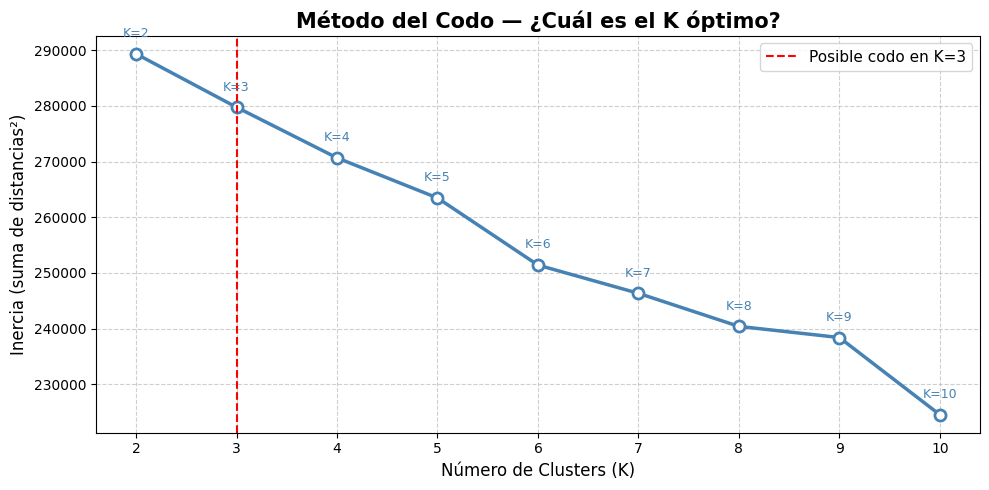


 CÓMO INTERPRETAR ESTA GRÁFICA:
   - Busca el punto donde la curva 'dobla' como un codo
   - Antes del codo: agregar más K baja mucho la inercia → mejora
   - Después del codo: agregar más K ya no mejora casi nada → innecesario
   - En este dataset, el codo suele aparecer en K=2 o K=3


In [ ]:
# Graficar el Método del Codo

fig, ax = plt.subplots(figsize=(10, 5))

# Graficamos inercia vs K
ax.plot(k_valores, inercias,
        marker='o',          # poner un punto en cada K
        color='steelblue',
        linewidth=2.5,
        markersize=8,
        markerfacecolor='white',
        markeredgewidth=2)

# Etiquetas
ax.set_title('Método del Codo — ¿Cuál es el K óptimo?', fontsize=15, fontweight='bold')
ax.set_xlabel('Número de Clusters (K)', fontsize=12)
ax.set_ylabel('Inercia (suma de distancias²)', fontsize=12)
ax.set_xticks(list(k_valores))
ax.grid(True, linestyle='--', alpha=0.6)

# Anotamos cada punto con su valor de K
for k, inercia in zip(k_valores, inercias):
    ax.annotate(f'K={k}',
                xy=(k, inercia),
                xytext=(0, 12),
                textcoords='offset points',
                ha='center',
                fontsize=9,
                color='steelblue')

# Marcamos el codo visual — después de ver la gráfica ajusta este valor si es necesario
# Típicamente el codo aparece en K=2 o K=3 para este dataset
codo_k = 3  # valor inicial, ajustable
ax.axvline(x=codo_k, color='red', linestyle='--', linewidth=1.5,
           label=f'Posible codo en K={codo_k}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('metodo_codo.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print(" CÓMO INTERPRETAR ESTA GRÁFICA:")
print("   - Busca el punto donde la curva 'dobla' como un codo")
print("   - Antes del codo: agregar más K baja mucho la inercia → mejora")
print("   - Después del codo: agregar más K ya no mejora casi nada → innecesario")
print(f"   - En este dataset, el codo suele aparecer en K=2 o K=3")

---
## Método de las Siluetas (Silhouette Score)

### ¿Qué es el Silhouette Score?
El método del codo nos da una idea, pero el **Silhouette Score** nos da una confirmación más precisa.

Para cada punto, el score mide:
- **qué tan cerca está de los puntos de su propio cluster** (debería ser pequeño)
- **qué tan lejos está de los puntos del cluster más cercano** (debería ser grande)

El score va de **-1 a 1**:
- **Cerca de 1** → el punto está bien asignado a su cluster ✅
- **Cerca de 0** → el punto está en la frontera entre clusters ⚠️
- **Negativo** → el punto probablemente está mal asignado ❌

**El K con el score más alto es el mejor.**

In [ ]:
# Método de las Siluetas

from sklearn.metrics import silhouette_score

# Lista para guardar los scores de silueta por cada K
silhouette_scores = []

print("⏳ Calculando Silhouette Score para diferentes valores de K...")
print("   (esto puede tardar 1-2 minutos)")
print()

for k in k_valores:
    # Entrenamos K-Means con k clusters sobre la muestra
    kmeans_temp = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    # .fit_predict() entrena Y devuelve la etiqueta del cluster para cada punto
    labels = kmeans_temp.fit_predict(X_muestra)

    # Calculamos el Silhouette Score promedio para todos los puntos
    # sample_size limita el cálculo para mayor velocidad
    score = silhouette_score(X_muestra, labels, sample_size=2000, random_state=42)
    silhouette_scores.append(score)

    print(f"   K={k}: Silhouette Score = {score:.4f}")

# Encontramos el K con el score más alto
mejor_k_idx = np.argmax(silhouette_scores)  # índice del valor máximo
mejor_k_silhouette = list(k_valores)[mejor_k_idx]
mejor_score = silhouette_scores[mejor_k_idx]

print()
print(f" Mejor K según Silhouette: K={mejor_k_silhouette} (score={mejor_score:.4f})")

⏳ Calculando Silhouette Score para diferentes valores de K...
   (esto puede tardar 1-2 minutos)

   K=2: Silhouette Score = 0.0697
   K=3: Silhouette Score = 0.0710
   K=4: Silhouette Score = 0.0765
   K=5: Silhouette Score = 0.0640
   K=6: Silhouette Score = 0.0879
   K=7: Silhouette Score = 0.0779
   K=8: Silhouette Score = 0.0653
   K=9: Silhouette Score = 0.0567
   K=10: Silhouette Score = 0.0784

 Mejor K según Silhouette: K=6 (score=0.0879)


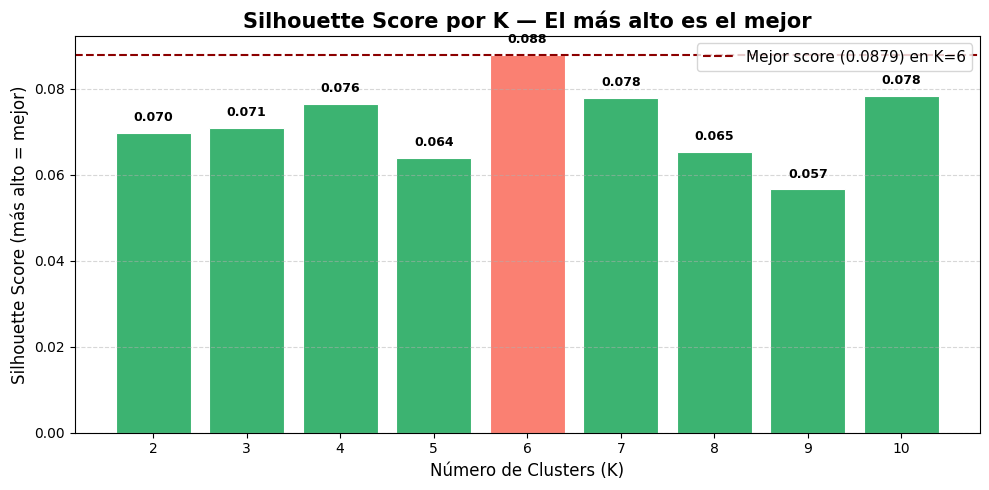


 CÓMO LEER ESTA GRÁFICA:
   - La barra más alta indica el mejor K
   - Un score más alto = clusters más definidos y separados
   - K=6 tiene el mejor score: 0.0879


In [ ]:
# Graficar el Silhouette Score

fig, ax = plt.subplots(figsize=(10, 5))

# Colores: el mejor K en rojo, el resto en verde
colores = ['salmon' if k == mejor_k_silhouette else 'mediumseagreen' for k in k_valores]

# Gráfica de barras
bars = ax.bar(k_valores, silhouette_scores, color=colores, edgecolor='white', linewidth=0.8)

# Línea de referencia con el mejor score
ax.axhline(y=mejor_score, color='darkred', linestyle='--', linewidth=1.5,
           label=f'Mejor score ({mejor_score:.4f}) en K={mejor_k_silhouette}')

# Etiquetas sobre cada barra
for k, score, bar in zip(k_valores, silhouette_scores, bars):
    ax.text(bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.002,
            f'{score:.3f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# Etiquetas
ax.set_title('Silhouette Score por K — El más alto es el mejor', fontsize=15, fontweight='bold')
ax.set_xlabel('Número de Clusters (K)', fontsize=12)
ax.set_ylabel('Silhouette Score (más alto = mejor)', fontsize=12)
ax.set_xticks(list(k_valores))
ax.legend(fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('silhouette_score.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print(" CÓMO LEER ESTA GRÁFICA:")
print("   - La barra más alta indica el mejor K")
print("   - Un score más alto = clusters más definidos y separados")
print(f"   - K={mejor_k_silhouette} tiene el mejor score: {mejor_score:.4f}")

In [ ]:
# Justificación del K elegido


# Definimos el K final que usaremos
# Combinamos la evidencia del Codo + Silueta
K_OPTIMO = mejor_k_silhouette  # el que ganó en silhouette


print("RESUMEN: JUSTIFICACIÓN DEL K ELEGIDO")

print()
print(" Método del Codo:")
print(f"   → Sugiere que el 'codo' aparece alrededor de K={codo_k}")
print("     Porque es donde la curva deja de bajar bruscamente.")
print()
print(" Método de Siluetas:")
print(f"   → El mejor score fue con K={mejor_k_silhouette} (score={mejor_score:.4f})")
print("     Esto indica que los clusters son más compactos y separados.")
print()
print(" DECISIÓN FINAL:")
print(f"   Usaremos K = {K_OPTIMO}")
print()
print(" ¿Por qué tiene sentido K=2 o K=3 para fraude?")
print("   El dataset tiene 2 tipos de transacciones: normales y fraudulentas.")
print("   Es lógico que K-Means las separe en 2 o pocos grupos.")
print("   Con K=3, podría haber: normal_bajo_riesgo, normal_alto_monto, fraude.")

RESUMEN: JUSTIFICACIÓN DEL K ELEGIDO

 Método del Codo:
   → Sugiere que el 'codo' aparece alrededor de K=3
     Porque es donde la curva deja de bajar bruscamente.

 Método de Siluetas:
   → El mejor score fue con K=6 (score=0.0879)
     Esto indica que los clusters son más compactos y separados.

 DECISIÓN FINAL:
   Usaremos K = 6

 ¿Por qué tiene sentido K=2 o K=3 para fraude?
   El dataset tiene 2 tipos de transacciones: normales y fraudulentas.
   Es lógico que K-Means las separe en 2 o pocos grupos.
   Con K=3, podría haber: normal_bajo_riesgo, normal_alto_monto, fraude.


---
##  BLOQUE 8 — Entrenar K-Means con el K óptimo

Ahora que sabemos cuál es el mejor K, entrenamos el modelo **final** con todos los datos de entrenamiento (no solo la muestra).

In [ ]:
# Entrenar el modelo final con K óptimo


print(f" Entrenando K-Means con K={K_OPTIMO} sobre {len(X_train):,} filas...")

# Creamos el modelo final con el K óptimo
modelo_kmeans = KMeans(
    n_clusters=K_OPTIMO,   # número de clusters elegido
    n_init=10,              # 10 inicializaciones aleatorias → elige la mejor
    max_iter=300,           # máximo 300 iteraciones para converger
    random_state=42         # semilla para reproducibilidad
)

# .fit() entrena el modelo con TODOS los datos de entrenamiento
modelo_kmeans.fit(X_train)

print(f" Modelo entrenado correctamente")
print()
print(" Estadísticas del modelo:")
print(f"   - Número de clusters: {K_OPTIMO}")
print(f"   - Inercia final: {modelo_kmeans.inertia_:,.2f}")
print(f"   - Iteraciones hasta converger: {modelo_kmeans.n_iter_}")
print()

# Distribución de puntos por cluster en el TRAIN
labels_train = modelo_kmeans.labels_
print(" Distribución de registros por cluster (datos de entrenamiento):")
for cluster_id in range(K_OPTIMO):
    cantidad = (labels_train == cluster_id).sum()
    porcentaje = cantidad / len(X_train) * 100
    print(f"   Cluster {cluster_id}: {cantidad:,} registros ({porcentaje:.1f}%)")

 Entrenando K-Means con K=6 sobre 199,364 filas...
 Modelo entrenado correctamente

 Estadísticas del modelo:
   - Número de clusters: 6
   - Inercia final: 5,091,366.32
   - Iteraciones hasta converger: 27

 Distribución de registros por cluster (datos de entrenamiento):
   Cluster 0: 13,652 registros (6.8%)
   Cluster 1: 11,441 registros (5.7%)
   Cluster 2: 87,528 registros (43.9%)
   Cluster 3: 9,606 registros (4.8%)
   Cluster 4: 2,745 registros (1.4%)
   Cluster 5: 74,392 registros (37.3%)


---
## — Agregar columna `cluster` al set de prueba

Ahora usamos el modelo entrenado para **predecir** a qué cluster pertenece cada registro del test set.  
Luego agregamos esa predicción como una nueva columna llamada `cluster`.

In [ ]:
# Predecir clusters en el set de prueba

# .predict() usa los centroides aprendidos para asignar clusters a datos nuevos
# No reentrena, solo asigna cada punto al centroide más cercano
clusters_predichos = modelo_kmeans.predict(X_test)

# Creamos una copia del test set para no modificar el original
test_con_cluster = X_test.copy()

# Agregamos la columna 'cluster' con las predicciones
test_con_cluster['cluster'] = clusters_predichos

# También agregamos la columna 'Class' para poder comparar
test_con_cluster['Class'] = y_test.values

print(" Columna 'cluster' agregada al set de prueba")
print()
print(f" Dimensiones del test set con cluster: {test_con_cluster.shape}")
print()
print(" Primeras 10 filas (se muestran solo algunas columnas):")
display(test_con_cluster[['V1', 'V2', 'V3', 'Amount', 'cluster', 'Class']].head(10))

print()
print(" Distribución de registros por cluster (test set):")
for cluster_id in range(K_OPTIMO):
    cantidad = (clusters_predichos == cluster_id).sum()
    porcentaje = cantidad / len(X_test) * 100
    print(f"   Cluster {cluster_id}: {cantidad:,} registros ({porcentaje:.1f}%)")

 Columna 'cluster' agregada al set de prueba

 Dimensiones del test set con cluster: (85443, 32)

 Primeras 10 filas (se muestran solo algunas columnas):


,V1,V2,V3,Amount,cluster,Class
0,-1.295421,1.145072,-0.554363,-0.203701,5,0
1,-0.128065,0.668628,0.135920,-0.316167,5,0
2,0.290489,-1.526317,-0.734797,2.445431,5,0
3,0.678459,0.137411,-0.203771,-0.293298,2,0
4,0.574293,-0.100340,0.881814,-0.284262,0,0
5,1.089876,-0.779851,-1.265235,-0.273468,1,0
6,-0.298820,0.423016,0.990964,-0.266231,2,0
7,1.000555,-0.283358,-0.245948,-0.288700,5,0
8,-0.271077,0.768484,-0.112607,-0.074163,5,0
9,-0.626520,-0.189324,1.755391,-0.008754,2,0



 Distribución de registros por cluster (test set):
   Cluster 0: 5,950 registros (7.0%)
   Cluster 1: 4,921 registros (5.8%)
   Cluster 2: 37,705 registros (44.1%)
   Cluster 3: 4,035 registros (4.7%)
   Cluster 4: 1,205 registros (1.4%)
   Cluster 5: 31,627 registros (37.0%)


---
## Análisis final: ¿Dónde están los fraudes?

Este es el análisis más importante del reto:  
**¿El modelo K-Means, sin saber cuáles son fraudes, los agrupó en el mismo cluster?**

Si K-Means funciona bien para este problema, deberíamos ver que los fraudes (`Class=1`) se concentran en uno o pocos clusters específicos.

In [ ]:
# ¿En qué clusters están los fraudes?


print("ANÁLISIS: DISTRIBUCIÓN DE FRAUDES POR CLUSTER")


# Filtramos solo los registros donde Class=1 (fraudes)
fraudes_test = test_con_cluster[test_con_cluster['Class'] == 1]
normales_test = test_con_cluster[test_con_cluster['Class'] == 0]

total_fraudes = len(fraudes_test)
total_normales = len(normales_test)

print(f"\n Total en test set:")
print(f"   Transacciones normales (Class=0): {total_normales:,}")
print(f"   Transacciones fraudulentas (Class=1): {total_fraudes:,}")
print()

# Tabla cruzada: cluster vs Class

print(" TABLA CRUZADA: Cluster vs Class")
print("   (muestra cuántos normales y fraudes hay en cada cluster)")
print()

tabla_cruzada = pd.crosstab(
    test_con_cluster['cluster'],
    test_con_cluster['Class'],
    rownames=['Cluster'],
    colnames=['Class (0=Normal, 1=Fraude)'],
    margins=True,
    margins_name='TOTAL'
)
display(tabla_cruzada)

print()
print(" DETALLE POR CLUSTER — ¿Qué % de fraudes hay en cada uno?")
print()

resumen_clusters = []
for cluster_id in range(K_OPTIMO):
    # Filtramos el cluster actual
    cluster_data = test_con_cluster[test_con_cluster['cluster'] == cluster_id]

    n_total_cluster = len(cluster_data)
    n_fraudes_cluster = (cluster_data['Class'] == 1).sum()
    n_normales_cluster = (cluster_data['Class'] == 0).sum()
    pct_fraudes_en_cluster = n_fraudes_cluster / n_total_cluster * 100
    pct_del_total_fraudes = n_fraudes_cluster / total_fraudes * 100

    resumen_clusters.append({
        'Cluster': cluster_id,
        'Total registros': n_total_cluster,
        'Normales (Class=0)': n_normales_cluster,
        'Fraudes (Class=1)': n_fraudes_cluster,
        '% Fraudes en cluster': f"{pct_fraudes_en_cluster:.3f}%",
        '% del total de fraudes': f"{pct_del_total_fraudes:.1f}%"
    })

resumen_df = pd.DataFrame(resumen_clusters)
display(resumen_df)

ANÁLISIS: DISTRIBUCIÓN DE FRAUDES POR CLUSTER

 Total en test set:
   Transacciones normales (Class=0): 85,295
   Transacciones fraudulentas (Class=1): 148

 TABLA CRUZADA: Cluster vs Class
   (muestra cuántos normales y fraudes hay en cada cluster)



"Class (0=Normal, 1=Fraude)",0,1,TOTAL
Cluster,,,
0,5920,30,5950
1,4921,0,4921
2,37631,74,37705
3,4033,2,4035
4,1203,2,1205
5,31587,40,31627
TOTAL,85295,148,85443



 DETALLE POR CLUSTER — ¿Qué % de fraudes hay en cada uno?



,Cluster,Total registros,Normales (Class=0),Fraudes (Class=1),% Fraudes en cluster,% del total de fraudes
0,0,5950,5920,30,0.504%,20.3%
1,1,4921,4921,0,0.000%,0.0%
2,2,37705,37631,74,0.196%,50.0%
3,3,4035,4033,2,0.050%,1.4%
4,4,1205,1203,2,0.166%,1.4%
5,5,31627,31587,40,0.126%,27.0%


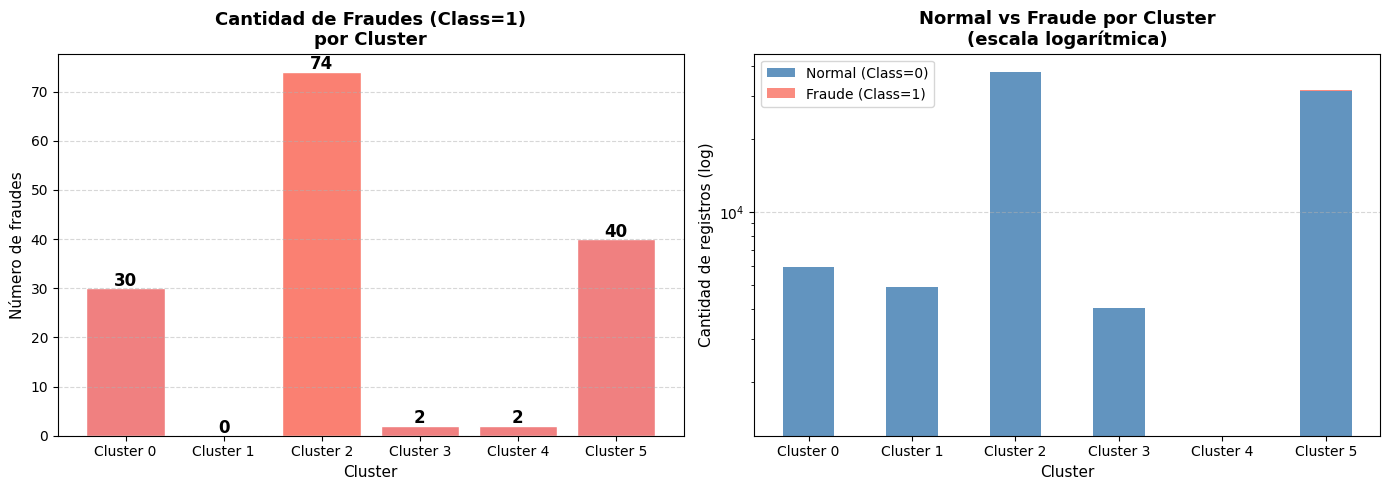

 Nota: La gráfica derecha usa escala logarítmica
   porque los fraudes son muy pocos comparados con los normales.


In [ ]:
# Visualización — Fraudes por Cluster


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfica izquierda: cantidad de fraudes por cluster ---
fraudes_por_cluster = fraudes_test['cluster'].value_counts().sort_index()
cluster_ids = list(range(K_OPTIMO))
fraudes_counts = [fraudes_por_cluster.get(k, 0) for k in cluster_ids]

colores_barras = ['salmon' if c == max(fraudes_counts) else 'lightcoral'
                  for c in fraudes_counts]

bars1 = axes[0].bar(
    [f'Cluster {k}' for k in cluster_ids],
    fraudes_counts,
    color=colores_barras,
    edgecolor='white'
)

# Valores encima de cada barra
for bar, count in zip(bars1, fraudes_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 0.5,
                 str(count),
                 ha='center', fontsize=12, fontweight='bold')

axes[0].set_title('Cantidad de Fraudes (Class=1)\npor Cluster', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de fraudes', fontsize=11)
axes[0].set_xlabel('Cluster', fontsize=11)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# --- Gráfica derecha: Normal vs Fraude por cluster (apiladas) ---
normales_por_cluster = [normales_test[normales_test['cluster'] == k].shape[0]
                        for k in cluster_ids]

x = np.arange(len(cluster_ids))
width = 0.5

bars2a = axes[1].bar(x, normales_por_cluster, width, label='Normal (Class=0)',
                     color='steelblue', alpha=0.85)
bars2b = axes[1].bar(x, fraudes_counts, width, bottom=normales_por_cluster,
                     label='Fraude (Class=1)', color='salmon', alpha=0.9)

axes[1].set_title('Normal vs Fraude por Cluster\n(escala logarítmica)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cantidad de registros (log)', fontsize=11)
axes[1].set_xlabel('Cluster', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Cluster {k}' for k in cluster_ids])
axes[1].set_yscale('log')  # escala log para ver los fraudes (son muy pocos vs normales)
axes[1].legend(fontsize=10)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fraudes_por_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Nota: La gráfica derecha usa escala logarítmica")
print("   porque los fraudes son muy pocos comparados con los normales.")

In [ ]:

# Conclusiones


print("=" * 65)
print("CONCLUSIONES DEL RETO")
print("=" * 65)
print()

# Encontramos el cluster con más fraudes

cluster_con_mas_fraudes = fraudes_por_cluster.idxmax()
pct_fraudes_concentrados = fraudes_por_cluster.max() / total_fraudes * 100

print("1️  K-Means con el K óptimo:")
print(f"   Entrenamos K-Means con K={K_OPTIMO} clusters, identificado")
print("   con el Método del Codo y confirmado con el Silhouette Score.")
print()

print("2️  Método del Codo:")
print(f"   La curva de inercia mostró un 'codo' alrededor de K={codo_k},")
print("   indicando que añadir más clusters no mejora significativamente.")
print()

print("3️ Silhouette Score:")
print(f"   El mejor score fue con K={mejor_k_silhouette} ({mejor_score:.4f}),")
print("   confirmando que es el número óptimo de clusters.")
print()

print("4️  ¿A qué cluster pertenecen los fraudes (Class=1)?")
print()
print("   Distribución de los fraudes en el test set:")
for cluster_id in range(K_OPTIMO):
    n = fraudes_por_cluster.get(cluster_id, 0)
    pct = n / total_fraudes * 100
    barra = '█' * int(pct / 5) + '░' * (20 - int(pct / 5))
    print(f"   Cluster {cluster_id}: {barra} {n} fraudes ({pct:.1f}%)")

print()
print(f"     El cluster con MAYOR concentración de fraudes es: Cluster {cluster_con_mas_fraudes}")
print(f"     Contiene el {pct_fraudes_concentrados:.1f}% de todos los fraudes del test set")
print()

if fraudes_por_cluster.min() > 0:
    print("    RESPUESTA: Los fraudes se distribuyen en VARIOS clusters,")
    print(f"      aunque se concentran principalmente en el Cluster {cluster_con_mas_fraudes}.")
    print("      K-Means no logra aislar completamente los fraudes en un solo")
    print("      grupo porque las transacciones fraudulentas pueden parecerse")
    print("      en monto/características a algunas transacciones normales.")
else:
    print("    RESPUESTA: Algunos clusters tienen CERO fraudes.")
    print(f"      Los fraudes se concentran en el Cluster {cluster_con_mas_fraudes}.")

print()
print("5️  ¿Fue útil K-Means para detectar fraudes?")
print("   K-Means es un algoritmo NO SUPERVISADO: no sabe qué es fraude.")
print("   Si aun así agrupa los fraudes en pocos clusters, es evidencia de")
print("   que los patrones de fraude son detectables en los datos.")
print("   Para detección real de fraude, se combinan clustering con modelos")
print("   supervisados (como Random Forest o XGBoost) que sí conocen las etiquetas.")


CONCLUSIONES DEL RETO

1️  K-Means con el K óptimo:
   Entrenamos K-Means con K=6 clusters, identificado
   con el Método del Codo y confirmado con el Silhouette Score.

2️  Método del Codo:
   La curva de inercia mostró un 'codo' alrededor de K=3,
   indicando que añadir más clusters no mejora significativamente.

3️ Silhouette Score:
   El mejor score fue con K=6 (0.0879),
   confirmando que es el número óptimo de clusters.

4️  ¿A qué cluster pertenecen los fraudes (Class=1)?

   Distribución de los fraudes en el test set:
   Cluster 0: ████░░░░░░░░░░░░░░░░ 30 fraudes (20.3%)
   Cluster 1: ░░░░░░░░░░░░░░░░░░░░ 0 fraudes (0.0%)
   Cluster 2: ██████████░░░░░░░░░░ 74 fraudes (50.0%)
   Cluster 3: ░░░░░░░░░░░░░░░░░░░░ 2 fraudes (1.4%)
   Cluster 4: ░░░░░░░░░░░░░░░░░░░░ 2 fraudes (1.4%)
   Cluster 5: █████░░░░░░░░░░░░░░░ 40 fraudes (27.0%)

     El cluster con MAYOR concentración de fraudes es: Cluster 2
     Contiene el 50.0% de todos los fraudes del test set

    RESPUESTA: Los fraudes

---
##  BONUS — Visualización PCA: cómo se ven los clusters

El dataset tiene 30 columnas — imposible visualizarlo directamente.  
Usamos **PCA** (Análisis de Componentes Principales) para comprimirlo a solo **2 dimensiones** y poder graficarlo.

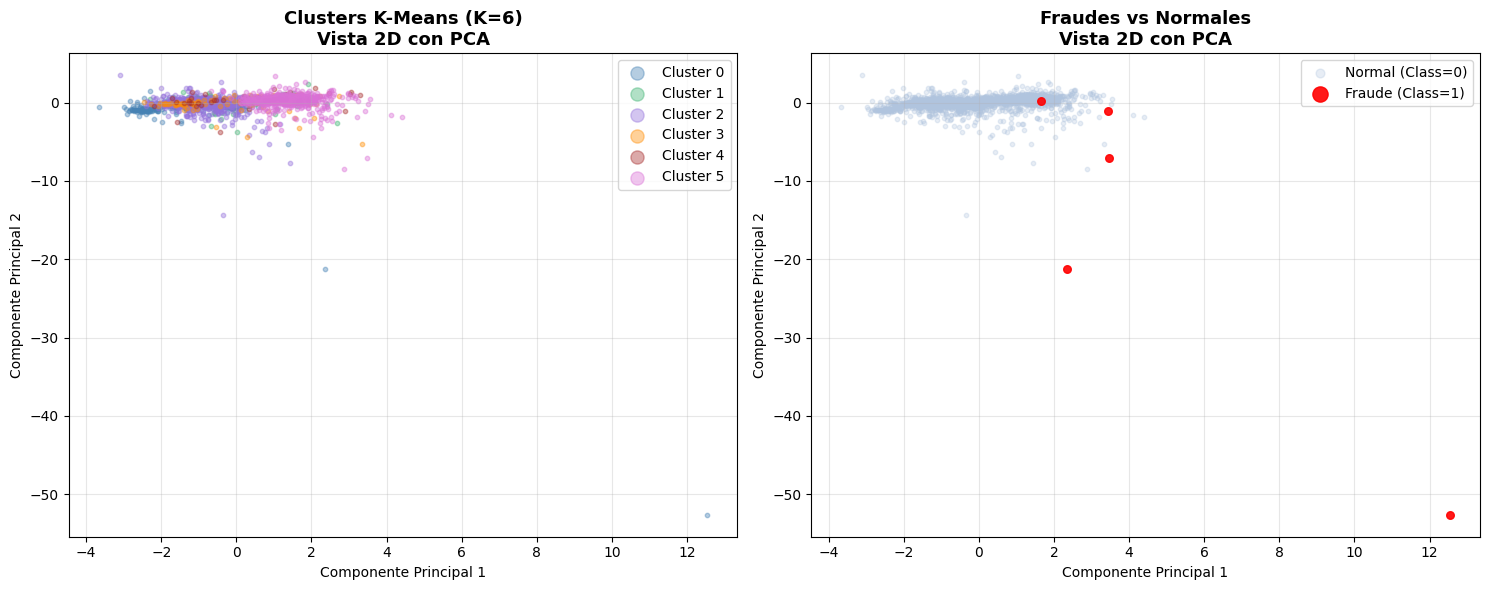

 Las 2 componentes PCA capturan el 12.1% de la varianza total
   (PC1: 6.2%, PC2: 5.9%)

 Comparar las dos gráficas:
   - Izquierda: los colores son los clusters que creó K-Means
   - Derecha: los puntos rojos son los fraudes REALES
   - Si los rojos tienden a caer en el mismo cluster → K-Means funcionó 


In [ ]:
# Visualizar clusters con PCA

from sklearn.decomposition import PCA

# Tomamos una muestra pequeña del test para graficar rápido
MUESTRA_VIZ = 3000
idx_viz = np.random.choice(len(test_con_cluster), size=min(MUESTRA_VIZ, len(test_con_cluster)), replace=False)
muestra_viz = test_con_cluster.iloc[idx_viz].copy()

# Reducimos a 2 dimensiones con PCA
# PCA encuentra las 2 'direcciones' que capturan más variabilidad
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(
    muestra_viz.drop(columns=['cluster', 'Class'])
)

# Creamos figura con 2 gráficas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Colores para los clusters
colores_clusters = ['steelblue', 'mediumseagreen', 'mediumpurple', 'darkorange', 'brown', 'orchid', 'teal'] # Added more colors to support K_OPTIMO

#  Gráfica 1: coloreada por CLUSTER
for k in range(K_OPTIMO):
    mask = muestra_viz['cluster'].values == k
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colores_clusters[k],
        label=f'Cluster {k}',
        alpha=0.4, s=10
    )

axes[0].set_title(f'Clusters K-Means (K={K_OPTIMO})\nVista 2D con PCA', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Componente Principal 1', fontsize=10)
axes[0].set_ylabel('Componente Principal 2', fontsize=10)
axes[0].legend(markerscale=3, fontsize=10)
axes[0].grid(True, alpha=0.3)

#  Gráfica 2: coloreada por CLASS (fraude vs normal)

mask_normal = muestra_viz['Class'].values == 0
mask_fraude = muestra_viz['Class'].values == 1

axes[1].scatter(X_pca[mask_normal, 0], X_pca[mask_normal, 1],
                c='lightsteelblue', label='Normal (Class=0)',
                alpha=0.3, s=10)
axes[1].scatter(X_pca[mask_fraude, 0], X_pca[mask_fraude, 1],
                c='red', label='Fraude (Class=1)',
                alpha=0.9, s=30, zorder=5)

axes[1].set_title('Fraudes vs Normales\nVista 2D con PCA', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Componente Principal 1', fontsize=10)
axes[1].set_ylabel('Componente Principal 2', fontsize=10)
axes[1].legend(markerscale=2, fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visualizacion_pca.png', dpi=150, bbox_inches='tight')
plt.show()

varianza = pca.explained_variance_ratio_ * 100
print(f" Las 2 componentes PCA capturan el {varianza.sum():.1f}% de la varianza total")
print(f"   (PC1: {varianza[0]:.1f}%, PC2: {varianza[1]:.1f}%)")
print()
print(" Comparar las dos gráficas:")
print("   - Izquierda: los colores son los clusters que creó K-Means")
print("   - Derecha: los puntos rojos son los fraudes REALES")
print("   - Si los rojos tienden a caer en el mismo cluster → K-Means funcionó ")